# Descarga De Datos

In [1]:
from datetime import datetime
from dateutil.relativedelta import relativedelta

# Asumiendo que min_date_str y max_date_str están disponibles de la ejecución de la celda anterior
# Si no, necesitarías ejecutar la celda anterior nuevamente o establecerlos manualmente
# Nota: Como comentamos la celda anterior, necesitarás definir min_date_str y max_date_str manualmente
# Por ejemplo:
min_date_str = '2015-01-01T00:00:00.000' # Reemplaza con la fecha mínima real si la conoces
max_date_str = '2026-08-09T23:59:59.999' # Reemplaza con la fecha máxima real si la conoces


fecha_min = datetime.fromisoformat(min_date_str.replace('Z', '+00:00')) if 'Z' in min_date_str else datetime.fromisoformat(min_date_str)
fecha_max = datetime.fromisoformat(max_date_str.replace('Z', '+00:00')) if 'Z' in max_date_str else datetime.fromisoformat(max_date_str)

rangos_trimestrales = []
fecha_inicio_actual = fecha_min

while fecha_inicio_actual <= fecha_max:
    fin_de_trimestre = fecha_inicio_actual + relativedelta(months=3) - relativedelta(days=1)
    # Asegurar que la fecha de fin no exceda la fecha_max
    if fin_de_trimestre > fecha_max:
        fin_de_trimestre = fecha_max

    rangos_trimestrales.append((fecha_inicio_actual, fin_de_trimestre))

    fecha_inicio_actual = fecha_inicio_actual + relativedelta(months=3)

# Mostrar los rangos trimestrales generados
for inicio, fin in rangos_trimestrales:
    print(f"Inicio: {inicio.strftime('%Y-%m-%d')}, Fin: {fin.strftime('%Y-%m-%d')}")

Inicio: 2015-01-01, Fin: 2015-03-31
Inicio: 2015-04-01, Fin: 2015-06-30
Inicio: 2015-07-01, Fin: 2015-09-30
Inicio: 2015-10-01, Fin: 2015-12-31
Inicio: 2016-01-01, Fin: 2016-03-31
Inicio: 2016-04-01, Fin: 2016-06-30
Inicio: 2016-07-01, Fin: 2016-09-30
Inicio: 2016-10-01, Fin: 2016-12-31
Inicio: 2017-01-01, Fin: 2017-03-31
Inicio: 2017-04-01, Fin: 2017-06-30
Inicio: 2017-07-01, Fin: 2017-09-30
Inicio: 2017-10-01, Fin: 2017-12-31
Inicio: 2018-01-01, Fin: 2018-03-31
Inicio: 2018-04-01, Fin: 2018-06-30
Inicio: 2018-07-01, Fin: 2018-09-30
Inicio: 2018-10-01, Fin: 2018-12-31
Inicio: 2019-01-01, Fin: 2019-03-31
Inicio: 2019-04-01, Fin: 2019-06-30
Inicio: 2019-07-01, Fin: 2019-09-30
Inicio: 2019-10-01, Fin: 2019-12-31
Inicio: 2020-01-01, Fin: 2020-03-31
Inicio: 2020-04-01, Fin: 2020-06-30
Inicio: 2020-07-01, Fin: 2020-09-30
Inicio: 2020-10-01, Fin: 2020-12-31
Inicio: 2021-01-01, Fin: 2021-03-31
Inicio: 2021-04-01, Fin: 2021-06-30
Inicio: 2021-07-01, Fin: 2021-09-30
Inicio: 2021-10-01, Fin: 202

In [4]:
import requests
import pandas as pd
from dateutil.relativedelta import relativedelta
import time # Importar time para añadir retrasos
import os # Importar os para manipulación de rutas

# Asegúrate de que Google Drive esté montado antes de ejecutar esta celda
# from google.colab import drive
# drive.mount('/content/drive')


datos_trimestrales_completos = []
url = "https://www.datos.gov.co/resource/p6dx-8zbt.json" # URL corregida con el nuevo dataset ID
directorio_salida = '/content/drive/MyDrive/DatosAPI_Trimestral_Parquet/' # Directorio donde se guardarán los archivos en formato Parquet

# Crear el directorio si no existe
os.makedirs(directorio_salida, exist_ok=True)

# Asumiendo que rangos_trimestrales está disponible de la ejecución de la celda anterior

for fecha_inicio, fecha_fin in rangos_trimestrales:
    fecha_inicio_str = fecha_inicio.strftime('%Y-%m-%d')
    fecha_fin_str = fecha_fin.strftime('%Y-%m-%d')
    print(f"Obteniendo datos para el trimestre: {fecha_inicio_str} a {fecha_fin_str}")

    params = {
        "$where": f"fecha_de_publicacion_del >= '{fecha_inicio.strftime('%Y-%m-%dT%H:%M:%S')}' AND fecha_de_publicacion_del <= '{fecha_fin.strftime('%Y-%m-%dT%H:%M:%S')}'",
        "$limit": 5000000 # Límite aumentado, pero aún es bueno manejar la paginación potencial si es necesario
    }

    res = requests.get(url, params=params)

    if res.status_code == 200:
        data = res.json()
        if data: # Procesar solo si hay datos
            df_trimestre = pd.DataFrame(data)
            # Generar nombre del archivo basado en el rango de fechas con extensión .parquet
            nombre_archivo = f"datos_trimestre_{fecha_inicio.year}_Q{(fecha_inicio.month-1)//3 + 1}_{fecha_inicio_str}_to_{fecha_fin_str}.parquet"
            ruta_archivo = os.path.join(directorio_salida, nombre_archivo)
            df_trimestre.to_parquet(ruta_archivo, index=False) # Cambiado a to_parquet
            print(f"Guardados {len(data)} registros en {ruta_archivo}")
        else:
            print(f"No se obtuvieron registros para este trimestre: {fecha_inicio_str} a {fecha_fin_str}.")
    else:
        print(f"Error al obtener datos para {fecha_inicio_str} a {fecha_fin_str}: {res.status_code}")
        print(res.text) # Imprimir respuesta de error para depuración

    time.sleep(1) # Añadir un pequeño retraso para evitar saturar la API

print("Descarga de datos para todos los trimestres finalizada.")

Obteniendo datos para el trimestre: 2015-01-01 a 2015-03-31
No se obtuvieron registros para este trimestre: 2015-01-01 a 2015-03-31.
Obteniendo datos para el trimestre: 2015-04-01 a 2015-06-30
Guardados 313 registros en /content/drive/MyDrive/DatosAPI_Trimestral_Parquet/datos_trimestre_2015_Q2_2015-04-01_to_2015-06-30.parquet
Obteniendo datos para el trimestre: 2015-07-01 a 2015-09-30
Guardados 2617 registros en /content/drive/MyDrive/DatosAPI_Trimestral_Parquet/datos_trimestre_2015_Q3_2015-07-01_to_2015-09-30.parquet
Obteniendo datos para el trimestre: 2015-10-01 a 2015-12-31
Guardados 342 registros en /content/drive/MyDrive/DatosAPI_Trimestral_Parquet/datos_trimestre_2015_Q4_2015-10-01_to_2015-12-31.parquet
Obteniendo datos para el trimestre: 2016-01-01 a 2016-03-31
Guardados 596 registros en /content/drive/MyDrive/DatosAPI_Trimestral_Parquet/datos_trimestre_2016_Q1_2016-01-01_to_2016-03-31.parquet
Obteniendo datos para el trimestre: 2016-04-01 a 2016-06-30
Guardados 3002 registros e

In [5]:
import pandas as pd
import os

output_dir = '/content/drive/MyDrive/DatosAPI_Trimestral_Parquet/' # Directorio donde se guardaron los archivos parquet

# Obtener una lista de todos los archivos parquet en el directorio
all_files = [os.path.join(output_dir, f) for f in os.listdir(output_dir) if f.endswith('.parquet')]

if all_files:
    print(f"Se encontraron {len(all_files)} archivos Parquet.")
    # Seleccionar algunos archivos para verificar (por ejemplo, el primero, el del medio y el último)
    files_to_verify = []
    if len(all_files) >= 1:
        files_to_verify.append(all_files[0])
    if len(all_files) >= 2:
        files_to_verify.append(all_files[len(all_files) // 2])
    if len(all_files) >= 3:
        files_to_verify.append(all_files[-1])
    # Eliminar duplicados si los hay
    files_to_verify = list(set(files_to_verify))

    # Configurar opciones de pandas para mostrar todas las columnas (opcional)
    pd.set_option('display.max_columns', None)

    for f in files_to_verify:
        print(f"\nVerificando archivo: {f}")
        try:
            df_verify = pd.read_parquet(f) # Cambiado a read_parquet
            print(f"Número de filas: {len(df_verify)}")
            print("Columnas:", df_verify.columns.tolist())
            display(df_verify.head())
        except Exception as e:
            print(f"Error al leer el archivo {f}: {e}")

    # Restablecer opciones de pandas (opcional)
    # pd.reset_option('display.max_columns')

else:
    print("No se encontraron archivos Parquet en el directorio especificado.")

Se encontraron 43 archivos Parquet.

Verificando archivo: /content/drive/MyDrive/DatosAPI_Trimestral_Parquet/datos_trimestre_2017_Q3_2017-07-01_to_2017-09-30.parquet
Número de filas: 11369
Columnas: ['entidad', 'nit_entidad', 'departamento_entidad', 'ciudad_entidad', 'ordenentidad', 'codigo_pci', 'id_del_proceso', 'referencia_del_proceso', 'ppi', 'id_del_portafolio', 'nombre_del_procedimiento', 'descripci_n_del_procedimiento', 'fase', 'fecha_de_publicacion_del', 'fecha_de_ultima_publicaci', 'fecha_de_publicacion_fase_3', 'precio_base', 'modalidad_de_contratacion', 'justificaci_n_modalidad_de', 'duracion', 'unidad_de_duracion', 'fecha_de_recepcion_de', 'ciudad_de_la_unidad_de', 'nombre_de_la_unidad_de', 'proveedores_invitados', 'proveedores_con_invitacion', 'visualizaciones_del', 'proveedores_que_manifestaron', 'respuestas_al_procedimiento', 'respuestas_externas', 'conteo_de_respuestas_a_ofertas', 'proveedores_unicos_con', 'numero_de_lotes', 'estado_del_procedimiento', 'id_estado_del_pr

,entidad,nit_entidad,departamento_entidad,ciudad_entidad,ordenentidad,codigo_pci,id_del_proceso,referencia_del_proceso,ppi,id_del_portafolio,nombre_del_procedimiento,descripci_n_del_procedimiento,fase,fecha_de_publicacion_del,fecha_de_ultima_publicaci,fecha_de_publicacion_fase_3,precio_base,modalidad_de_contratacion,justificaci_n_modalidad_de,duracion,unidad_de_duracion,fecha_de_recepcion_de,ciudad_de_la_unidad_de,nombre_de_la_unidad_de,proveedores_invitados,proveedores_con_invitacion,visualizaciones_del,proveedores_que_manifestaron,respuestas_al_procedimiento,respuestas_externas,conteo_de_respuestas_a_ofertas,proveedores_unicos_con,numero_de_lotes,estado_del_procedimiento,id_estado_del_procedimiento,adjudicado,id_adjudicacion,codigoproveedor,departamento_proveedor,ciudad_proveedor,valor_total_adjudicacion,nombre_del_adjudicador,nombre_del_proveedor,nit_del_proveedor_adjudicado,codigo_principal_de_categoria,estado_de_apertura_del_proceso,tipo_de_contrato,subtipo_de_contrato,categorias_adicionales,urlproceso,codigo_entidad,estado_resumen,fecha_de_apertura_de_respuesta,fecha_de_apertura_efectiva,fecha_adjudicacion,fecha_de_publicacion,fecha_de_publicacion_fase_2
0,ICANH,830067892,Distrito Capital de Bogotá,Bogotá,Nacional,Centralizada,CO1.REQ.185901,CTO 245 2017,701159022,CO1.BDOS.182601,Prestar servicios profesionales para realizar ...,Prestar servicios profesionales para realizar ...,Presentación de oferta,2017-07-01T00:00:00.000,2017-07-01T00:00:00.000,2017-07-01T00:00:00.000,15000000,Contratación Directa (con ofertas),Ejecución de trabajos artísticos,150,día(s),2017-07-05T00:00:00.000,No Aplica,Oficina de Contratos,1,1,1,0,1,0,0,1,0,Cancelado,100,No,No Adjudicado,No Definido,No Definido,No Definido,0,No Adjudicado,No Definido,No Definido,V1.80111500,Abierto,Prestación de servicios,No Definido,No definido,{'url': 'https://community.secop.gov.co/Public...,701159022,Presentación de oferta,None,None,None,None,None
1,ARMADA NACIONAL - BASE NAVAL No.1 ARC BOLÍVAR,800141645,Bolívar,Cartagena,Nacional,Centralizada,CO1.REQ.185522,106-ARC-CBN1-ADBN1-CGUCA-2017 (Manifestación d...,701189037,CO1.BDOS.177001,MANTENIMIENTO PREVENTIVO Y CORRECTIVO VEHICULO...,SERVICIO DE MANTENIMIENTO PREVENTIVO Y CORRECT...,Presentación de oferta,2017-07-01T00:00:00.000,2017-07-01T00:00:00.000,2017-07-01T00:00:00.000,0,Selección Abreviada de Menor Cuantía,Presupuesto menor al 10% de la Menor Cuantía,0,día(s),2017-07-06T00:00:00.000,Cartagena,BASE NAVAL ARC BOLIVAR,2,2,16,0,1,0,0,1,0,Seleccionado,70,Si,CO1.AWD.143428,701926313,Bolívar,Cartagena,91000000,Maira Luz Montiel Carrillo,AUTO TROPICAL CARTAGENA SAS,900466154,V1.78181500,Cerrado,Suministros,No Definido,No definido,{'url': 'https://community.secop.gov.co/Public...,701189037,Adjudicado,2017-07-06T00:00:00.000,2017-07-06T00:00:00.000,2017-07-27T00:00:00.000,None,None
2,POLICIA METROPOLITANA DE IBAGUE,900486439,Tolima,No Definido,Nacional,Descentralizada,CO1.REQ.185603,PN METIB SA MC 050 DE 2017 (Manifestación de i...,701695223,CO1.BDOS.177812,PRESTACIÓN DE LOS SERVICIOS DE RESTAURANTE  C...,PRESTACIÓN DE LOS SERVICIOS DE RESTAURANTE  C...,Manifestación de interés (Menor Cuantía),2017-07-01T00:00:00.000,2017-07-01T00:00:00.000,None,0,Selección Abreviada de Menor Cuantía,Presupuesto menor al 10% de la Menor Cuantía,6,Mes(es),2017-07-11T00:00:00.000,Ibagué,GRUPO DE CONTRATOS POLICIA METROPOLITANA DE IB...,0,0,54,0,0,0,0,0,0,Evaluación,60,No,No Adjudicado,No Definido,No Definido,No Definido,0,No Adjudicado,No Definido,No Definido,V1.93141506,Cerrado,Prestación de servicios,No Definido,"V180111500, V180141900, V190101500, V190101600...",{'url': 'https://community.secop.gov.co/Public...,701695223,Manifestación de interés (Menor Cuantía),2017-07-11T00:00:00.000,2017-07-11T00:00:00.000,None,2017-07-01T00:00:00.000,None
3,DEPARTAMENTO DE POLICIA CHOCO,800140951,Chocó,No Definido,Nacional,Centralizada,CO1.REQ.186001,PN DECHO MIC 017 2017,701694218,CO1.BDOS.182701,PROCESO MANTENIMIENTO COMPUTADORES,MANTENIMIEN


Verificando archivo: /content/drive/MyDrive/DatosAPI_Trimestral_Parquet/datos_trimestre_2021_Q3_2021-07-01_to_2021-09-30.parquet
Número de filas: 185425
Columnas: ['entidad', 'nit_entidad', 'departamento_entidad', 'ciudad_entidad', 'ordenentidad', 'codigo_pci', 'id_del_proceso', 'referencia_del_proceso', 'ppi', 'id_del_portafolio', 'nombre_del_procedimiento', 'descripci_n_del_procedimiento', 'fase', 'fecha_de_publicacion_del', 'fecha_de_ultima_publicaci', 'fecha_de_publicacion_fase_3', 'precio_base', 'modalidad_de_contratacion', 'justificaci_n_modalidad_de', 'duracion', 'unidad_de_duracion', 'ciudad_de_la_unidad_de', 'nombre_de_la_unidad_de', 'proveedores_invitados', 'proveedores_con_invitacion', 'visualizaciones_del', 'proveedores_que_manifestaron', 'respuestas_al_procedimiento', 'respuestas_externas', 'conteo_de_respuestas_a_ofertas', 'proveedores_unicos_con', 'numero_de_lotes', 'estado_del_procedimiento', 'id_estado_del_procedimiento', 'adjudicado', 'id_adjudicacion', 'codigoprovee

,entidad,nit_entidad,departamento_entidad,ciudad_entidad,ordenentidad,codigo_pci,id_del_proceso,referencia_del_proceso,ppi,id_del_portafolio,nombre_del_procedimiento,descripci_n_del_procedimiento,fase,fecha_de_publicacion_del,fecha_de_ultima_publicaci,fecha_de_publicacion_fase_3,precio_base,modalidad_de_contratacion,justificaci_n_modalidad_de,duracion,unidad_de_duracion,ciudad_de_la_unidad_de,nombre_de_la_unidad_de,proveedores_invitados,proveedores_con_invitacion,visualizaciones_del,proveedores_que_manifestaron,respuestas_al_procedimiento,respuestas_externas,conteo_de_respuestas_a_ofertas,proveedores_unicos_con,numero_de_lotes,estado_del_procedimiento,id_estado_del_procedimiento,adjudicado,id_adjudicacion,codigoproveedor,departamento_proveedor,ciudad_proveedor,valor_total_adjudicacion,nombre_del_adjudicador,nombre_del_proveedor,nit_del_proveedor_adjudicado,codigo_principal_de_categoria,estado_de_apertura_del_proceso,tipo_de_contrato,subtipo_de_contrato,categorias_adicionales,urlproceso,codigo_entidad,estado_resumen,fecha_de_recepcion_de,fecha_de_apertura_de_respuesta,fecha_de_apertura_efectiva,fecha_adjudicacion,fecha_de_publicacion_fase_2,fecha_de_publicacion
0,MUNICIPIO DE SOACHA..,800094755,Cundinamarca,Soacha,Territorial,Centralizada,CO1.REQ.2125604,2035-2021,702158254,CO1.BDOS.2066785,PRESTACION DE SERVICIOS DE APOYO A LA GESTION,PRESTACION DE SERVICIOS DE APOYO A LA GESTION ...,Fase de ofertas,2021-07-01T00:00:00.000,2021-07-01T00:00:00.000,2021-07-01T00:00:00.000,13126667,Contratación directa,Servicios profesionales y apoyo a la gestión,179,día(s),Soacha,SECRETARIA DE PLANEACION,0,0,0,0,0,0,0,0,0,Seleccionado,70,No,No Adjudicado,714468154,Cundinamarca,Soacha,0,No Adjudicado,DIDIER RIVERA QUINTERO,1104694135,V1.80111600,Abierto,Prestación de servicios,No Definido,No definido,{'url': 'https://community.secop.gov.co/Public...,702158254,Adjudicado,None,None,None,None,None,None
1,COMANDO GAULA MILITARES (COGAM),900457470,Distrito Capital de Bogotá,No Definido,Nacional,Centralizada,CO1.REQ.2118632,037-DIGAU-2021,702865569,CO1.BDOS.2061005,ELEMENTOS DE FERRETERIA,CONTRATAR EL SUMINISTRO DE MATERIALES DE CONST...,Presentación de oferta,2021-07-01T00:00:00.000,2021-07-01T00:00:00.000,2021-07-01T00:00:00.000,22244103,Mínima cuantía,Presupuesto inferior al 10% de la menor cuantía,4,Mes(es),No Aplica,COMANDO GENERAL -DIRECCIÓN NACIONAL DE GAULAS,0,0,12,0,0,0,0,2,0,Seleccionado,70,Si,CO1.AWD.1062441,704141464,Distrito Capital de Bogotá,Bogotá,22244103,MARIANA ARBOLEDA COMBARIZA,G&M COMERCIALIZADORA SAS,900730436,V1.46181504,Cerrado,Suministros,No Definido,"V111121606, V112352310, V126121616, V127111918...",{'url': 'https://community.secop.gov.co/Public...,702865569,Adjudicado,2021-07-02T00:00:00.000,2021-07-02T00:00:00.000,2021-07-02T00:00:00.000,2021-07-09T00:00:00.000,None,None
2,INDER ENVIGADO1,811016337,Antioquia,Envigado,Territorial,Descentralizada,CO1.REQ.2121192,20210515,706490067,CO1.BDOS.2053448,Transporte en los diferentes eventos,Prestación de servicios de transporte terrestr...,Clarification submission,2021-07-01T00:00:00.000,2021-07-01T00:00:00.000,None,176269032,Selección abreviada subasta inversa,Suministro de bienes y servicios de caracterís...,134,día(s),No Aplica,Gestión Administrativa,0,0,39,0,0,0,0,0,0,Evaluación,60,No,No Adjudicado,No Definido,No Definido,No Definido,0,No Adjudicado,No Definido,No Definido,V1.78111803,Cerrado,Prestación de servicios,No Definido,V178111800,{'url': 'https://community.secop.gov.co/Public...,706490067,Clarification submission,2021-07-22T00:00:00.000,2021-08-03T00:00:00.000,2021-07-22T00:00:00.000,None,2021-07-01T00:00:00.000,None
3,UNIDAD ADMINISTRATIVA ESPECIAL DE SALUD DE ARAUCA,900034608,Arauca,No Definido,Territorial,Centralizada,CO1.REQ.2125831,01-592-2021,700587157,CO1.BDOS.2067411,PRESTACIÓN DE SERVICIOS TÉCNICOS PARA EL FORTA...,PRESTACIÓN DE SERVICIOS TÉCNICOS PARA EL FORTA...,Fase de ofertas,2021-07-01T00:00:00.000,2021-07-01T00:00:00.000,2021-07-01T00:00:00.000,8376872,Co


Verificando archivo: /content/drive/MyDrive/DatosAPI_Trimestral_Parquet/datos_trimestre_2022_Q3_2022-07-01_to_2022-09-30.parquet
Número de filas: 313827
Columnas: ['entidad', 'nit_entidad', 'departamento_entidad', 'ciudad_entidad', 'ordenentidad', 'codigo_pci', 'id_del_proceso', 'referencia_del_proceso', 'ppi', 'id_del_portafolio', 'nombre_del_procedimiento', 'descripci_n_del_procedimiento', 'fase', 'fecha_de_publicacion_del', 'fecha_de_ultima_publicaci', 'fecha_de_publicacion_fase_3', 'precio_base', 'modalidad_de_contratacion', 'justificaci_n_modalidad_de', 'duracion', 'unidad_de_duracion', 'ciudad_de_la_unidad_de', 'nombre_de_la_unidad_de', 'proveedores_invitados', 'proveedores_con_invitacion', 'visualizaciones_del', 'proveedores_que_manifestaron', 'respuestas_al_procedimiento', 'respuestas_externas', 'conteo_de_respuestas_a_ofertas', 'proveedores_unicos_con', 'numero_de_lotes', 'estado_del_procedimiento', 'id_estado_del_procedimiento', 'adjudicado', 'id_adjudicacion', 'codigoprovee

,entidad,nit_entidad,departamento_entidad,ciudad_entidad,ordenentidad,codigo_pci,id_del_proceso,referencia_del_proceso,ppi,id_del_portafolio,nombre_del_procedimiento,descripci_n_del_procedimiento,fase,fecha_de_publicacion_del,fecha_de_ultima_publicaci,fecha_de_publicacion_fase_3,precio_base,modalidad_de_contratacion,justificaci_n_modalidad_de,duracion,unidad_de_duracion,ciudad_de_la_unidad_de,nombre_de_la_unidad_de,proveedores_invitados,proveedores_con_invitacion,visualizaciones_del,proveedores_que_manifestaron,respuestas_al_procedimiento,respuestas_externas,conteo_de_respuestas_a_ofertas,proveedores_unicos_con,numero_de_lotes,estado_del_procedimiento,id_estado_del_procedimiento,adjudicado,id_adjudicacion,codigoproveedor,departamento_proveedor,ciudad_proveedor,valor_total_adjudicacion,nombre_del_adjudicador,nombre_del_proveedor,nit_del_proveedor_adjudicado,codigo_principal_de_categoria,estado_de_apertura_del_proceso,tipo_de_contrato,subtipo_de_contrato,categorias_adicionales,urlproceso,codigo_entidad,estado_resumen,fecha_de_recepcion_de,fecha_de_apertura_de_respuesta,fecha_de_apertura_efectiva,fecha_adjudicacion,fecha_de_publicacion_fase_2,fecha_de_publicacion
0,Institución Universitaria Pascual Bravo COMPRADOR,8909801583,Antioquia,Medellín,Nacional,Centralizada,CO1.REQ.3083909,GJ 078 DE 2022,712721034,CO1.BDOS.3001416,GJ 078 DE 2022,"Prestación de servicios profesionales, por su ...",Fase de ofertas,2022-07-01T00:00:00.000,2022-07-01T00:00:00.000,2022-07-01T00:00:00.000,35731500,Contratación directa,Servicios profesionales y apoyo a la gestión,166,día(s),Medellín,Gestión Jurídica,0,0,0,0,0,0,0,0,0,Seleccionado,70,No,No Adjudicado,713305506,Antioquia,Medellín,0,No Adjudicado,Cristina Buitrago Bedoya,32241896,V1.80111600,Abierto,Prestación de servicios,No Definido,No definido,{'url': 'https://community.secop.gov.co/Public...,712721034,Adjudicado,None,None,None,None,None,None
1,INSTITUTO DE DEPORTES Y RECREACION DE MEDELLIN,800194096,Antioquia,Medellín,Territorial,Descentralizada,CO1.REQ.3085011,6700024540,700774011,CO1.BDOS.3002508,PRESTAR LOS SERVICIOS PROFESIONALES ESPECIALIZ...,PRESTAR LOS SERVICIOS PROFESIONALES ESPECIALIZ...,Fase de ofertas,2022-07-01T00:00:00.000,2022-07-01T00:00:00.000,2022-07-01T00:00:00.000,36816000,Contratación directa,Servicios profesionales y apoyo a la gestión,6,Mes(es),Medellín,OFICINA ASESORA DE PLANEACION,0,0,0,0,0,0,0,0,0,Seleccionado,70,No,No Adjudicado,713483980,Antioquia,Medellín,0,No Adjudicado,JENNIFER MEJÍA PULGARIN,43977793,V1.80111601,Abierto,Prestación de servicios,No Definido,No definido,{'url': 'https://community.secop.gov.co/Public...,700774011,Adjudicado,None,None,None,None,None,None
2,INSTITUTO MUNICIPAL DEL DEPORTE Y LA RECREACIO...,815000340,Valle del Cauca,No Definido,Territorial,Centralizada,CO1.REQ.3083336,130-2022,704258151,CO1.BDOS.3000726,NATALIA RODRIGUEZ MORALES,PRESTACION DE SERVICIOS PROFESIONALES COM ABOG...,Presentación de oferta,2022-07-01T00:00:00.000,2022-07-01T00:00:00.000,2022-07-01T00:00:00.000,21000000,Contratación directa,Servicios profesionales y apoyo a la gestión,6,Mes(es),Palmira,IMDER PALMIRA,0,0,0,0,0,0,0,0,0,Seleccionado,70,No,No Adjudicado,718253412,Valle del Cauca,Cali,0,No Adjudicado,NATALIA RODRIGUEZ MORALES,38556055,V1.80111620,Abierto,Prestación de servicios,No Definido,No definido,{'url': 'https://community.secop.gov.co/Public...,704258151,Adjudicado,None,None,None,None,None,None
3,SANTIAGO DE CALI DISTRITO ESPECIAL -DEPARTAMEN...,890399011,Valle del Cauca,Cali,Territorial,Centralizada,CO1.REQ.3078916,4137.010.32.1.138-2022,704025808,CO1.BDOS.2996434,Prestar los servicios Profesionales con el fin...,Prestar los servicios Profesionales con el fin...,Fase de ofertas,2022-07-01T00:00:00.000,2022-07-01T00:00:00.000,2022-07-01T00:00:00.000,21138000,Contratación directa,Servicios profesionales y apoyo a la gestión,175,día(s),Cali,CONTRATACION DADII,0,0,0,0,0,0,0,0,0,Seleccionado,70,No,No Adjudicado,705480150,Valle del Cauca,No Definido,0,No Adjudicado

# Analisis de ultimo año de estudio


1) Unir 4 trimestres y filtrar ≥ 2025-01-01

In [8]:
import os, glob, pandas as pd
from datetime import datetime

BASE_DIR = "/content/drive/MyDrive/DatosAPI_Trimestral_Parquet/"
# ajusta los cuatro nombres si ya los conoces; o usa un patrón por año/quarter
files = sorted(glob.glob(os.path.join(BASE_DIR, "datos_trimestre_2025_Q*.parquet")))[:4]

df = pd.concat((pd.read_parquet(f) for f in files), ignore_index=True)

# asegurar tipo datetime
for c in ("fecha_de_publicacion_del","fecha_de_ultima_publicaci","fecha_adjudicacion"):
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")

cut = pd.Timestamp("2025-01-01")
df_2025p = df[df["fecha_de_publicacion_del"].ge(cut)].copy()

print(len(files), "archivos unidos,", len(df_2025p), "registros ≥ 2025-01-01")


4 archivos unidos, 1555467 registros ≥ 2025-01-01


2) Esquema estrella + unicidad del “proceso”

In [9]:
# define el orden: qué versión conservar por proceso
df_2025p["orden_ver"] = df_2025p["fecha_de_ultima_publicaci"].fillna(df_2025p["fecha_de_publicacion_del"])
df_last = (df_2025p
           .sort_values(["id_del_proceso","orden_ver"])
           .groupby("id_del_proceso", as_index=False)
           .tail(1)  # última publicación por proceso
           .drop(columns=["orden_ver"]))


Generamos una tabla que elimina los registros con mismo codigo de proceso y  solo mantenemos los que tiene ulitma fehca de publicacion

In [10]:
num_original_rows = len(df_2025p)
num_deduplicated_rows = len(df_last)
num_removed_rows = num_original_rows - num_deduplicated_rows

print(f"Número de registros originales: {num_original_rows}")
print(f"Número de registros después de la deduplicación: {num_deduplicated_rows}")
print(f"Número de registros eliminados: {num_removed_rows}")

# Para mostrar algunos de los registros eliminados, podemos encontrar los IDs de proceso duplicados
# y mostrar algunas filas del dataframe original que no están en el dataframe deduplicado.

# Encontrar los IDs de proceso que se eliminaron (los que tenían duplicados y no fueron la última versión)
removed_process_ids = df_2025p[~df_2025p['id_del_proceso'].isin(df_last['id_del_proceso'])]['id_del_proceso'].unique()

print(f"\nEjemplos de IDs de proceso con registros eliminados ({len(removed_process_ids)} IDs únicos):")
# Mostrar algunos registros originales para los primeros IDs de proceso eliminados
sample_removed_ids = removed_process_ids[:5] # Mostrar ejemplos para los primeros 5 IDs

for process_id in sample_removed_ids:
    print(f"\nRegistros originales para el proceso ID: {process_id}")
    display(df_2025p[df_2025p['id_del_proceso'] == process_id])

Número de registros originales: 1555467
Número de registros después de la deduplicación: 1444351
Número de registros eliminados: 111116

Ejemplos de IDs de proceso con registros eliminados (0 IDs únicos):


generamos una tabla en la que miramos que columnas difieren en los registros que estamos eliminando


In [11]:
# Identificar los IDs de proceso que tienen duplicados (es decir, los que se eliminaron)
duplicate_process_ids = df_2025p[df_2025p.duplicated(subset='id_del_proceso', keep=False)]['id_del_proceso'].unique()

print(f"Número de IDs de proceso con registros duplicados: {len(duplicate_process_ids)}")

# Seleccionar algunos ejemplos de IDs de proceso con duplicados para mostrar las diferencias
if len(duplicate_process_ids) > 0:
    # Mostrar ejemplos para los primeros 3 IDs duplicados (puedes ajustar este número)
    sample_duplicate_ids = duplicate_process_ids[:3]

    for sample_process_id in sample_duplicate_ids:
        print(f"\nMostrando diferencias para un ID de proceso de ejemplo: {sample_process_id}")

        # Filtrar el dataframe original para el ID de proceso de ejemplo
        df_original_process = df_2025p[df_2025p['id_del_proceso'] == sample_process_id].copy()

        # Convertir columnas de tipo diccionario o lista a string para permitir la comparación
        for col in df_original_process.columns:
            if df_original_process[col].apply(lambda x: isinstance(x, (dict, list))).any():
                 df_original_process[col] = df_original_process[col].astype(str)

        # Encontrar las columnas que tienen valores diferentes en los registros de este proceso
        diff_cols = []
        if len(df_original_process) > 1:
            first_row = df_original_process.iloc[0]
            for col in df_original_process.columns:
                # Usamos .nunique() para verificar si hay más de un valor único en la columna para este grupo
                if df_original_process[col].nunique() > 1:
                    diff_cols.append(col)

        if diff_cols:
            print(f"\nColumnas que difieren para el proceso ID {sample_process_id}: {diff_cols}")
            print("\nRegistros originales para este proceso, mostrando todas las columnas:")
            # Mostrar todas las columnas para estos registros duplicados
            display(df_2025p[df_2025p['id_del_proceso'] == sample_process_id])
        else:
            print("\nNo se encontraron columnas que difieran en los registros de este proceso de ejemplo.")

else:
    print("\nNo se encontraron IDs de proceso con registros duplicados en df_2025p.")

Número de IDs de proceso con registros duplicados: 21427

Mostrando diferencias para un ID de proceso de ejemplo: CO1.REQ.7383534

Columnas que difieren para el proceso ID CO1.REQ.7383534: ['codigoproveedor', 'departamento_proveedor', 'ciudad_proveedor', 'nombre_del_proveedor', 'nit_del_proveedor_adjudicado']

Registros originales para este proceso, mostrando todas las columnas:


,entidad,nit_entidad,departamento_entidad,ciudad_entidad,ordenentidad,codigo_pci,id_del_proceso,referencia_del_proceso,ppi,id_del_portafolio,nombre_del_procedimiento,descripci_n_del_procedimiento,fase,fecha_de_publicacion_del,fecha_de_ultima_publicaci,fecha_de_publicacion_fase_3,precio_base,modalidad_de_contratacion,justificaci_n_modalidad_de,duracion,unidad_de_duracion,ciudad_de_la_unidad_de,nombre_de_la_unidad_de,proveedores_invitados,proveedores_con_invitacion,visualizaciones_del,proveedores_que_manifestaron,respuestas_al_procedimiento,respuestas_externas,conteo_de_respuestas_a_ofertas,proveedores_unicos_con,numero_de_lotes,estado_del_procedimiento,id_estado_del_procedimiento,adjudicado,id_adjudicacion,codigoproveedor,departamento_proveedor,ciudad_proveedor,valor_total_adjudicacion,nombre_del_adjudicador,nombre_del_proveedor,nit_del_proveedor_adjudicado,codigo_principal_de_categoria,estado_de_apertura_del_proceso,tipo_de_contrato,subtipo_de_contrato,categorias_adicionales,urlproceso,codigo_entidad,estado_resumen,fecha_de_recepcion_de,fecha_de_apertura_efectiva,fecha_de_apertura_de_respuesta,fecha_adjudicacion,fecha_de_publicacion_fase_2,fecha_de_publicacion,orden_ver
82,E.S.E HOSPITAL SAN RAFAEL DE CAQUEZA,832001411,Cundinamarca,Caqueza,Territorial,Descentralizada,CO1.REQ.7383534,HSRC-014-2025,703015735,CO1.BDOS.7247233,PRESTAR SERVICIO DE APOYO A LA GESTION COMO AU...,PRESTAR SERVICIO DE APOYO A LA GESTION COMO AU...,Presentación de oferta,2025-01-01,2025-01-01,2025-01-01T00:00:00.000,16000000,Contratación régimen especial,Decreto 092 de 2017,8,Mes(es),Caqueza,OFICINA DE CONTRATACIÓN,0,0,0,0,0,0,0,0,0,Seleccionado,70,No,No Adjudicado,729840058,Cundinamarca,Caqueza,0,No Adjudicado,JENNY CATHERINE CRUZ CARRILLO,39731461,V1.80111715,Abierto,Decreto 092 de 2017,No Definido,No definido,{'url': 'https://community.secop.gov.co/Public...,703015735,Adjudicado,None,None,None,NaT,None,None,2025-01-01
899,E.S.E HOSPITAL SAN RAFAEL DE CAQUEZA,832001411,Cundinamarca,Caqueza,Territorial,Descentralizada,CO1.REQ.7383534,HSRC-014-2025,703015735,CO1.BDOS.7247233,PRESTAR SERVICIO DE APOYO A LA GESTION COMO AU...,PRESTAR SERVICIO DE APOYO A LA GESTION COMO AU...,Presentación de oferta,2025-01-01,2025-01-01,2025-01-01T00:00:00.000,16000000,Contratación régimen especial,Decreto 092 de 2017,8,Mes(es),Caqueza,OFICINA DE CONTRATACIÓN,0,0,0,0,0,0,0,0,0,Seleccionado,70,No,No Adjudicado,No Definido,No Definido,No Definido,0,No Adjudicado,No Definido,No Definido,V1.80111715,Abierto,Decreto 092 de 2017,No Definido,No definido,{'url': 'https://community.secop.gov.co/Public...,703015735,Adjudicado,None,None,None,NaT,None,None,2025-01-01



Mostrando diferencias para un ID de proceso de ejemplo: CO1.REQ.7383611

Columnas que difieren para el proceso ID CO1.REQ.7383611: ['codigoproveedor', 'departamento_proveedor', 'ciudad_proveedor', 'nombre_del_proveedor', 'nit_del_proveedor_adjudicado']

Registros originales para este proceso, mostrando todas las columnas:


,entidad,nit_entidad,departamento_entidad,ciudad_entidad,ordenentidad,codigo_pci,id_del_proceso,referencia_del_proceso,ppi,id_del_portafolio,nombre_del_procedimiento,descripci_n_del_procedimiento,fase,fecha_de_publicacion_del,fecha_de_ultima_publicaci,fecha_de_publicacion_fase_3,precio_base,modalidad_de_contratacion,justificaci_n_modalidad_de,duracion,unidad_de_duracion,ciudad_de_la_unidad_de,nombre_de_la_unidad_de,proveedores_invitados,proveedores_con_invitacion,visualizaciones_del,proveedores_que_manifestaron,respuestas_al_procedimiento,respuestas_externas,conteo_de_respuestas_a_ofertas,proveedores_unicos_con,numero_de_lotes,estado_del_procedimiento,id_estado_del_procedimiento,adjudicado,id_adjudicacion,codigoproveedor,departamento_proveedor,ciudad_proveedor,valor_total_adjudicacion,nombre_del_adjudicador,nombre_del_proveedor,nit_del_proveedor_adjudicado,codigo_principal_de_categoria,estado_de_apertura_del_proceso,tipo_de_contrato,subtipo_de_contrato,categorias_adicionales,urlproceso,codigo_entidad,estado_resumen,fecha_de_recepcion_de,fecha_de_apertura_efectiva,fecha_de_apertura_de_respuesta,fecha_adjudicacion,fecha_de_publicacion_fase_2,fecha_de_publicacion,orden_ver
109,ALEJANDRO PROSPERO REVEREND E.S.E.,819004070,Magdalena,Santa Marta,Territorial,Descentralizada,CO1.REQ.7383611,PS-127-2025,704290097,CO1.BDOS.7247315,APOYAR A LA SUBGERENCIA ADMINISTRATIVA EN LA O...,APOYAR A LA SUBGERENCIA ADMINISTRATIVA EN LA O...,Presentación de oferta,2025-01-01,2025-01-01,2025-01-01T00:00:00.000,4800000,Contratación régimen especial,Regla aplicable,2,Mes(es),Santa Marta,OFICINA JURIDICA ASESORA,0,0,0,0,0,0,0,0,0,Seleccionado,70,No,No Adjudicado,720563071,Magdalena,Santa Marta,0,No Adjudicado,SANDRA LILIANA BENEDETTI DIAZ,52704821,V1.84111506,Abierto,Prestación de servicios,No Definido,No definido,{'url': 'https://community.secop.gov.co/Public...,704290097,Adjudicado,None,None,None,NaT,None,None,2025-01-01
749,ALEJANDRO PROSPERO REVEREND E.S.E.,819004070,Magdalena,Santa Marta,Territorial,Descentralizada,CO1.REQ.7383611,PS-127-2025,704290097,CO1.BDOS.7247315,APOYAR A LA SUBGERENCIA ADMINISTRATIVA EN LA O...,APOYAR A LA SUBGERENCIA ADMINISTRATIVA EN LA O...,Presentación de oferta,2025-01-01,2025-01-01,2025-01-01T00:00:00.000,4800000,Contratación régimen especial,Regla aplicable,2,Mes(es),Santa Marta,OFICINA JURIDICA ASESORA,0,0,0,0,0,0,0,0,0,Seleccionado,70,No,No Adjudicado,No Definido,No Definido,No Definido,0,No Adjudicado,No Definido,No Definido,V1.84111506,Abierto,Prestación de servicios,No Definido,No definido,{'url': 'https://community.secop.gov.co/Public...,704290097,Adjudicado,None,None,None,NaT,None,None,2025-01-01



Mostrando diferencias para un ID de proceso de ejemplo: CO1.REQ.7382981

Columnas que difieren para el proceso ID CO1.REQ.7382981: ['codigoproveedor', 'ciudad_proveedor', 'nombre_del_proveedor', 'nit_del_proveedor_adjudicado']

Registros originales para este proceso, mostrando todas las columnas:


,entidad,nit_entidad,departamento_entidad,ciudad_entidad,ordenentidad,codigo_pci,id_del_proceso,referencia_del_proceso,ppi,id_del_portafolio,nombre_del_procedimiento,descripci_n_del_procedimiento,fase,fecha_de_publicacion_del,fecha_de_ultima_publicaci,fecha_de_publicacion_fase_3,precio_base,modalidad_de_contratacion,justificaci_n_modalidad_de,duracion,unidad_de_duracion,ciudad_de_la_unidad_de,nombre_de_la_unidad_de,proveedores_invitados,proveedores_con_invitacion,visualizaciones_del,proveedores_que_manifestaron,respuestas_al_procedimiento,respuestas_externas,conteo_de_respuestas_a_ofertas,proveedores_unicos_con,numero_de_lotes,estado_del_procedimiento,id_estado_del_procedimiento,adjudicado,id_adjudicacion,codigoproveedor,departamento_proveedor,ciudad_proveedor,valor_total_adjudicacion,nombre_del_adjudicador,nombre_del_proveedor,nit_del_proveedor_adjudicado,codigo_principal_de_categoria,estado_de_apertura_del_proceso,tipo_de_contrato,subtipo_de_contrato,categorias_adicionales,urlproceso,codigo_entidad,estado_resumen,fecha_de_recepcion_de,fecha_de_apertura_efectiva,fecha_de_apertura_de_respuesta,fecha_adjudicacion,fecha_de_publicacion_fase_2,fecha_de_publicacion,orden_ver
180,ESE HOSPITAL UNIVERSITARIO JULIO MENDEZ BARREN...,891780185,Magdalena,Santa Marta,Territorial,Centralizada,CO1.REQ.7382981,PC-2025-0005-APOYO ADMINISTRATIVO-1,705278133,CO1.BDOS.7246786,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO ...,PRESTACIÓN DE SERVICIOS DE APOYO A LA GESTIÓN ...,Presentación de oferta,2025-01-01,2025-01-01,2025-01-01T00:00:00.000,28800000,Contratación régimen especial,Regla aplicable,3,Mes(es),Santa Marta,Grupo de contratación SECOP II,0,0,0,0,0,0,0,0,0,Seleccionado,70,No,No Adjudicado,712908631,Magdalena,Santa Marta,0,No Adjudicado,INGRID JHOANA OSPINO LIZCANO,30061842,V1.80111700,Abierto,Prestación de servicios,No Definido,No definido,{'url': 'https://community.secop.gov.co/Public...,705278133,Adjudicado,None,None,None,NaT,None,None,2025-01-01
356,ESE HOSPITAL UNIVERSITARIO JULIO MENDEZ BARREN...,891780185,Magdalena,Santa Marta,Territorial,Centralizada,CO1.REQ.7382981,PC-2025-0005-APOYO ADMINISTRATIVO-1,705278133,CO1.BDOS.7246786,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO ...,PRESTACIÓN DE SERVICIOS DE APOYO A LA GESTIÓN ...,Presentación de oferta,2025-01-01,2025-01-01,2025-01-01T00:00:00.000,28800000,Contratación régimen especial,Regla aplicable,3,Mes(es),Santa Marta,Grupo de contratación SECOP II,0,0,0,0,0,0,0,0,0,Seleccionado,70,No,No Adjudicado,727928681,Magdalena,Santa Marta,0,No Adjudicado,CRISTINA ELENA CAMACHO FONTALVO,1004372812,V1.80111700,Abierto,Prestación de servicios,No Definido,No definido,{'url': 'https://community.secop.gov.co/Public...,705278133,Adjudicado,None,None,None,NaT,None,None,2025-01-01
967,ESE HOSPITAL UNIVERSITARIO JULIO MENDEZ BARREN...,891780185,Magdalena,Santa Marta,Territorial,Centralizada,CO1.REQ.7382981,PC-2025-0005-APOYO ADMINISTRATIVO-1,705278133,CO1.BDOS.7246786,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO ...,PRESTACIÓN DE SERVICIOS DE APOYO A LA GESTIÓN ...,Presentación de oferta,2025-01-01,2025-01-01,2025-01-01T00:00:00.000,28800000,Contratación régimen especial,Regla aplicable,3,Mes(es),Santa Marta,Grupo de contratación SECOP II,0,0,0,0,0,0,0,0,0,Seleccionado,70,No,No Adjudicado,713324424,Magdalena,Santa Marta,0,No Adjudicado,wilmer alfonso redondo florian,1193225381,V1.80111700,Abierto,Prestación de servicios,No Definido,No definido,{'url': 'https://community.secop.gov.co/Public...,705278133,Adjudicado,None,None,None,NaT,None,None,2025-01-01
1007,ESE HOSPITAL UNIVERSITARIO JULIO MENDEZ BARREN...,891780185,Magdalena,Santa Marta,Territorial,Centralizada,CO1.REQ.7382981,PC-2025-0005-APOYO ADMINISTRATIVO-1,705278133,CO1.BDOS.7246786,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO ...,PRESTACIÓN DE SERVICIOS DE APOYO A LA GESTIÓN ...,Presentación de oferta,2025-01-01,2025-01-01,2025-01-01T00:00:00.000,28800000,Contratación régimen especial,Regla aplicable,3,Mes(es),Santa Marta,Grupo de contrat

Si se necesita nivel de contrato adjudicado: hay procesos con varias adjudicaciones o lotes. Cambio del grano a (id_del_proceso, id_adjudicacion) y deduplica por ese par:

In [12]:
if "id_adjudicacion" in df_2025p.columns:
    keys = ["id_del_proceso","id_adjudicacion"]
    df_2025p["orden_ver"] = df_2025p["fecha_de_ultima_publicaci"].fillna(df_2025p["fecha_de_publicacion_del"])
    df_last = (df_2025p
               .sort_values(keys+["orden_ver"])
               .groupby(keys, as_index=False)
               .tail(1)
               .drop(columns=["orden_ver"]))


In [13]:
# Identificar los pares (id_del_proceso, id_adjudicacion) que tienen duplicados en df_2025p
if "id_adjudicacion" in df_2025p.columns:
    duplicate_adjudication_keys = df_2025p[df_2025p.duplicated(subset=["id_del_proceso", "id_adjudicacion"], keep=False)][["id_del_proceso", "id_adjudicacion"]].drop_duplicates().values.tolist()

    print(f"Número de pares (Proceso, Adjudicación) con registros duplicados: {len(duplicate_adjudication_keys)}")

    # Seleccionar algunos ejemplos de pares duplicados para mostrar las diferencias
    if len(duplicate_adjudication_keys) > 0:
        # Mostrar ejemplos para los primeros 3 pares duplicados (puedes ajustar este número)
        sample_duplicate_keys = duplicate_adjudication_keys[:3]

        for process_id, adjudicacion_id in sample_duplicate_keys:
            print(f"\nMostrando diferencias para el par (Proceso, Adjudicación): ({process_id}, {adjudicacion_id})")

            # Filtrar el dataframe original para el par de ejemplo
            df_original_pair = df_2025p[(df_2025p['id_del_proceso'] == process_id) & (df_2025p['id_adjudicacion'] == adjudicacion_id)].copy()

            # Convertir columnas de tipo diccionario o lista a string para permitir la comparación
            for col in df_original_pair.columns:
                if df_original_pair[col].apply(lambda x: isinstance(x, (dict, list))).any():
                     df_original_pair[col] = df_original_pair[col].astype(str)

            # Encontrar las columnas que tienen valores diferentes en los registros de este par
            diff_cols = []
            if len(df_original_pair) > 1:
                first_row = df_original_pair.iloc[0]
                for col in df_original_pair.columns:
                    if df_original_pair[col].nunique() > 1:
                        diff_cols.append(col)

            if diff_cols:
                print(f"\nColumnas que difieren para el par ({process_id}, {adjudicacion_id}): {diff_cols}")
                print("\nRegistros originales para este par, mostrando todas las columnas:")
                # Mostrar todas las columnas para estos registros duplicados
                display(df_original_pair)
            else:
                print("\nNo se encontraron columnas que difieran en los registros de este par de ejemplo.")

    else:
        print("\nNo se encontraron pares (Proceso, Adjudicación) con registros duplicados.")
else:
    print("\nLa columna 'id_adjudicacion' no existe en el DataFrame.")

Número de pares (Proceso, Adjudicación) con registros duplicados: 20759

Mostrando diferencias para el par (Proceso, Adjudicación): (CO1.REQ.7383534, No Adjudicado)

Columnas que difieren para el par (CO1.REQ.7383534, No Adjudicado): ['codigoproveedor', 'departamento_proveedor', 'ciudad_proveedor', 'nombre_del_proveedor', 'nit_del_proveedor_adjudicado']

Registros originales para este par, mostrando todas las columnas:


,entidad,nit_entidad,departamento_entidad,ciudad_entidad,ordenentidad,codigo_pci,id_del_proceso,referencia_del_proceso,ppi,id_del_portafolio,nombre_del_procedimiento,descripci_n_del_procedimiento,fase,fecha_de_publicacion_del,fecha_de_ultima_publicaci,fecha_de_publicacion_fase_3,precio_base,modalidad_de_contratacion,justificaci_n_modalidad_de,duracion,unidad_de_duracion,ciudad_de_la_unidad_de,nombre_de_la_unidad_de,proveedores_invitados,proveedores_con_invitacion,visualizaciones_del,proveedores_que_manifestaron,respuestas_al_procedimiento,respuestas_externas,conteo_de_respuestas_a_ofertas,proveedores_unicos_con,numero_de_lotes,estado_del_procedimiento,id_estado_del_procedimiento,adjudicado,id_adjudicacion,codigoproveedor,departamento_proveedor,ciudad_proveedor,valor_total_adjudicacion,nombre_del_adjudicador,nombre_del_proveedor,nit_del_proveedor_adjudicado,codigo_principal_de_categoria,estado_de_apertura_del_proceso,tipo_de_contrato,subtipo_de_contrato,categorias_adicionales,urlproceso,codigo_entidad,estado_resumen,fecha_de_recepcion_de,fecha_de_apertura_efectiva,fecha_de_apertura_de_respuesta,fecha_adjudicacion,fecha_de_publicacion_fase_2,fecha_de_publicacion,orden_ver
82,E.S.E HOSPITAL SAN RAFAEL DE CAQUEZA,832001411,Cundinamarca,Caqueza,Territorial,Descentralizada,CO1.REQ.7383534,HSRC-014-2025,703015735,CO1.BDOS.7247233,PRESTAR SERVICIO DE APOYO A LA GESTION COMO AU...,PRESTAR SERVICIO DE APOYO A LA GESTION COMO AU...,Presentación de oferta,2025-01-01,2025-01-01,2025-01-01T00:00:00.000,16000000,Contratación régimen especial,Decreto 092 de 2017,8,Mes(es),Caqueza,OFICINA DE CONTRATACIÓN,0,0,0,0,0,0,0,0,0,Seleccionado,70,No,No Adjudicado,729840058,Cundinamarca,Caqueza,0,No Adjudicado,JENNY CATHERINE CRUZ CARRILLO,39731461,V1.80111715,Abierto,Decreto 092 de 2017,No Definido,No definido,{'url': 'https://community.secop.gov.co/Public...,703015735,Adjudicado,None,None,None,NaT,None,None,2025-01-01
899,E.S.E HOSPITAL SAN RAFAEL DE CAQUEZA,832001411,Cundinamarca,Caqueza,Territorial,Descentralizada,CO1.REQ.7383534,HSRC-014-2025,703015735,CO1.BDOS.7247233,PRESTAR SERVICIO DE APOYO A LA GESTION COMO AU...,PRESTAR SERVICIO DE APOYO A LA GESTION COMO AU...,Presentación de oferta,2025-01-01,2025-01-01,2025-01-01T00:00:00.000,16000000,Contratación régimen especial,Decreto 092 de 2017,8,Mes(es),Caqueza,OFICINA DE CONTRATACIÓN,0,0,0,0,0,0,0,0,0,Seleccionado,70,No,No Adjudicado,No Definido,No Definido,No Definido,0,No Adjudicado,No Definido,No Definido,V1.80111715,Abierto,Decreto 092 de 2017,No Definido,No definido,{'url': 'https://community.secop.gov.co/Public...,703015735,Adjudicado,None,None,None,NaT,None,None,2025-01-01



Mostrando diferencias para el par (Proceso, Adjudicación): (CO1.REQ.7383611, No Adjudicado)

Columnas que difieren para el par (CO1.REQ.7383611, No Adjudicado): ['codigoproveedor', 'departamento_proveedor', 'ciudad_proveedor', 'nombre_del_proveedor', 'nit_del_proveedor_adjudicado']

Registros originales para este par, mostrando todas las columnas:


,entidad,nit_entidad,departamento_entidad,ciudad_entidad,ordenentidad,codigo_pci,id_del_proceso,referencia_del_proceso,ppi,id_del_portafolio,nombre_del_procedimiento,descripci_n_del_procedimiento,fase,fecha_de_publicacion_del,fecha_de_ultima_publicaci,fecha_de_publicacion_fase_3,precio_base,modalidad_de_contratacion,justificaci_n_modalidad_de,duracion,unidad_de_duracion,ciudad_de_la_unidad_de,nombre_de_la_unidad_de,proveedores_invitados,proveedores_con_invitacion,visualizaciones_del,proveedores_que_manifestaron,respuestas_al_procedimiento,respuestas_externas,conteo_de_respuestas_a_ofertas,proveedores_unicos_con,numero_de_lotes,estado_del_procedimiento,id_estado_del_procedimiento,adjudicado,id_adjudicacion,codigoproveedor,departamento_proveedor,ciudad_proveedor,valor_total_adjudicacion,nombre_del_adjudicador,nombre_del_proveedor,nit_del_proveedor_adjudicado,codigo_principal_de_categoria,estado_de_apertura_del_proceso,tipo_de_contrato,subtipo_de_contrato,categorias_adicionales,urlproceso,codigo_entidad,estado_resumen,fecha_de_recepcion_de,fecha_de_apertura_efectiva,fecha_de_apertura_de_respuesta,fecha_adjudicacion,fecha_de_publicacion_fase_2,fecha_de_publicacion,orden_ver
109,ALEJANDRO PROSPERO REVEREND E.S.E.,819004070,Magdalena,Santa Marta,Territorial,Descentralizada,CO1.REQ.7383611,PS-127-2025,704290097,CO1.BDOS.7247315,APOYAR A LA SUBGERENCIA ADMINISTRATIVA EN LA O...,APOYAR A LA SUBGERENCIA ADMINISTRATIVA EN LA O...,Presentación de oferta,2025-01-01,2025-01-01,2025-01-01T00:00:00.000,4800000,Contratación régimen especial,Regla aplicable,2,Mes(es),Santa Marta,OFICINA JURIDICA ASESORA,0,0,0,0,0,0,0,0,0,Seleccionado,70,No,No Adjudicado,720563071,Magdalena,Santa Marta,0,No Adjudicado,SANDRA LILIANA BENEDETTI DIAZ,52704821,V1.84111506,Abierto,Prestación de servicios,No Definido,No definido,{'url': 'https://community.secop.gov.co/Public...,704290097,Adjudicado,None,None,None,NaT,None,None,2025-01-01
749,ALEJANDRO PROSPERO REVEREND E.S.E.,819004070,Magdalena,Santa Marta,Territorial,Descentralizada,CO1.REQ.7383611,PS-127-2025,704290097,CO1.BDOS.7247315,APOYAR A LA SUBGERENCIA ADMINISTRATIVA EN LA O...,APOYAR A LA SUBGERENCIA ADMINISTRATIVA EN LA O...,Presentación de oferta,2025-01-01,2025-01-01,2025-01-01T00:00:00.000,4800000,Contratación régimen especial,Regla aplicable,2,Mes(es),Santa Marta,OFICINA JURIDICA ASESORA,0,0,0,0,0,0,0,0,0,Seleccionado,70,No,No Adjudicado,No Definido,No Definido,No Definido,0,No Adjudicado,No Definido,No Definido,V1.84111506,Abierto,Prestación de servicios,No Definido,No definido,{'url': 'https://community.secop.gov.co/Public...,704290097,Adjudicado,None,None,None,NaT,None,None,2025-01-01



Mostrando diferencias para el par (Proceso, Adjudicación): (CO1.REQ.7382981, No Adjudicado)

Columnas que difieren para el par (CO1.REQ.7382981, No Adjudicado): ['codigoproveedor', 'ciudad_proveedor', 'nombre_del_proveedor', 'nit_del_proveedor_adjudicado']

Registros originales para este par, mostrando todas las columnas:


,entidad,nit_entidad,departamento_entidad,ciudad_entidad,ordenentidad,codigo_pci,id_del_proceso,referencia_del_proceso,ppi,id_del_portafolio,nombre_del_procedimiento,descripci_n_del_procedimiento,fase,fecha_de_publicacion_del,fecha_de_ultima_publicaci,fecha_de_publicacion_fase_3,precio_base,modalidad_de_contratacion,justificaci_n_modalidad_de,duracion,unidad_de_duracion,ciudad_de_la_unidad_de,nombre_de_la_unidad_de,proveedores_invitados,proveedores_con_invitacion,visualizaciones_del,proveedores_que_manifestaron,respuestas_al_procedimiento,respuestas_externas,conteo_de_respuestas_a_ofertas,proveedores_unicos_con,numero_de_lotes,estado_del_procedimiento,id_estado_del_procedimiento,adjudicado,id_adjudicacion,codigoproveedor,departamento_proveedor,ciudad_proveedor,valor_total_adjudicacion,nombre_del_adjudicador,nombre_del_proveedor,nit_del_proveedor_adjudicado,codigo_principal_de_categoria,estado_de_apertura_del_proceso,tipo_de_contrato,subtipo_de_contrato,categorias_adicionales,urlproceso,codigo_entidad,estado_resumen,fecha_de_recepcion_de,fecha_de_apertura_efectiva,fecha_de_apertura_de_respuesta,fecha_adjudicacion,fecha_de_publicacion_fase_2,fecha_de_publicacion,orden_ver
180,ESE HOSPITAL UNIVERSITARIO JULIO MENDEZ BARREN...,891780185,Magdalena,Santa Marta,Territorial,Centralizada,CO1.REQ.7382981,PC-2025-0005-APOYO ADMINISTRATIVO-1,705278133,CO1.BDOS.7246786,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO ...,PRESTACIÓN DE SERVICIOS DE APOYO A LA GESTIÓN ...,Presentación de oferta,2025-01-01,2025-01-01,2025-01-01T00:00:00.000,28800000,Contratación régimen especial,Regla aplicable,3,Mes(es),Santa Marta,Grupo de contratación SECOP II,0,0,0,0,0,0,0,0,0,Seleccionado,70,No,No Adjudicado,712908631,Magdalena,Santa Marta,0,No Adjudicado,INGRID JHOANA OSPINO LIZCANO,30061842,V1.80111700,Abierto,Prestación de servicios,No Definido,No definido,{'url': 'https://community.secop.gov.co/Public...,705278133,Adjudicado,None,None,None,NaT,None,None,2025-01-01
356,ESE HOSPITAL UNIVERSITARIO JULIO MENDEZ BARREN...,891780185,Magdalena,Santa Marta,Territorial,Centralizada,CO1.REQ.7382981,PC-2025-0005-APOYO ADMINISTRATIVO-1,705278133,CO1.BDOS.7246786,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO ...,PRESTACIÓN DE SERVICIOS DE APOYO A LA GESTIÓN ...,Presentación de oferta,2025-01-01,2025-01-01,2025-01-01T00:00:00.000,28800000,Contratación régimen especial,Regla aplicable,3,Mes(es),Santa Marta,Grupo de contratación SECOP II,0,0,0,0,0,0,0,0,0,Seleccionado,70,No,No Adjudicado,727928681,Magdalena,Santa Marta,0,No Adjudicado,CRISTINA ELENA CAMACHO FONTALVO,1004372812,V1.80111700,Abierto,Prestación de servicios,No Definido,No definido,{'url': 'https://community.secop.gov.co/Public...,705278133,Adjudicado,None,None,None,NaT,None,None,2025-01-01
967,ESE HOSPITAL UNIVERSITARIO JULIO MENDEZ BARREN...,891780185,Magdalena,Santa Marta,Territorial,Centralizada,CO1.REQ.7382981,PC-2025-0005-APOYO ADMINISTRATIVO-1,705278133,CO1.BDOS.7246786,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO ...,PRESTACIÓN DE SERVICIOS DE APOYO A LA GESTIÓN ...,Presentación de oferta,2025-01-01,2025-01-01,2025-01-01T00:00:00.000,28800000,Contratación régimen especial,Regla aplicable,3,Mes(es),Santa Marta,Grupo de contratación SECOP II,0,0,0,0,0,0,0,0,0,Seleccionado,70,No,No Adjudicado,713324424,Magdalena,Santa Marta,0,No Adjudicado,wilmer alfonso redondo florian,1193225381,V1.80111700,Abierto,Prestación de servicios,No Definido,No definido,{'url': 'https://community.secop.gov.co/Public...,705278133,Adjudicado,None,None,None,NaT,None,None,2025-01-01
1007,ESE HOSPITAL UNIVERSITARIO JULIO MENDEZ BARREN...,891780185,Magdalena,Santa Marta,Territorial,Centralizada,CO1.REQ.7382981,PC-2025-0005-APOYO ADMINISTRATIVO-1,705278133,CO1.BDOS.7246786,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO ...,PRESTACIÓN DE SERVICIOS DE APOYO A LA GESTIÓN ...,Presentación de oferta,2025-01-01,2025-01-01,2025-01-01T00:00:00.000,28800000,Contratación régimen especial,Regla aplicable,3,Mes(es),Santa Marta,Grupo de contrat

In [14]:
# Records eliminated in the first deduplication (by id_del_proceso)
# We need to re-create the df_last from the first deduplication step
df_last_process_only = (df_2025p
           .sort_values(["id_del_proceso","orden_ver"])
           .groupby("id_del_proceso", as_index=False)
           .tail(1))

eliminated_in_process_only_dedup = df_2025p[~df_2025p.index.isin(df_last_process_only.index)].copy()

# Records eliminated in the second deduplication (by id_del_proceso and id_adjudicacion)
# This is the df_last we currently have
eliminated_in_process_adjudication_dedup = df_2025p[~df_2025p.index.isin(df_last.index)].copy()

print(f"Número de registros eliminados en la primera deduplicación (solo por proceso): {len(eliminated_in_process_only_dedup)}")
print(f"Número de registros eliminados en la segunda deduplicación (por proceso y adjudicación): {len(eliminated_in_process_adjudication_dedup)}")

# Find records eliminated in the first but NOT the second
eliminated_only_in_process_dedup = eliminated_in_process_only_dedup[
    ~eliminated_in_process_only_dedup.index.isin(eliminated_in_process_adjudication_dedup.index)
]

# Find records eliminated in the second but NOT the first
eliminated_only_in_process_adjudication_dedup = eliminated_in_process_adjudication_dedup[
    ~eliminated_in_process_adjudication_dedup.index.isin(eliminated_in_process_only_dedup.index)
]

# Find records eliminated in BOTH deduplications
eliminated_in_both_dedups = eliminated_in_process_only_dedup[
    eliminated_in_process_only_dedup.index.isin(eliminated_in_process_adjudication_dedup.index)
]

print(f"\nRegistros eliminados solo en la primera deduplicación: {len(eliminated_only_in_process_dedup)}")
print(f"Registros eliminados solo en la segunda deduplicación: {len(eliminated_only_in_process_adjudication_dedup)}")
print(f"Registros eliminados en ambas deduplicaciones: {len(eliminated_in_both_dedups)}")

# Optionally, display some examples from each category
if len(eliminated_only_in_process_dedup) > 0:
    print("\nEjemplo de registros eliminados solo en la primera deduplicación:")
    display(eliminated_only_in_process_dedup.head())

if len(eliminated_only_in_process_adjudication_dedup) > 0:
    print("\nEjemplo de registros eliminados solo en la segunda deduplicación:")
    display(eliminated_only_in_process_adjudication_dedup.head())

if len(eliminated_in_both_dedups) > 0:
    print("\nEjemplo de registros eliminados en ambas deduplicaciones:")
    display(eliminated_in_both_dedups.head())

Número de registros eliminados en la primera deduplicación (solo por proceso): 111116
Número de registros eliminados en la segunda deduplicación (por proceso y adjudicación): 107065

Registros eliminados solo en la primera deduplicación: 4051
Registros eliminados solo en la segunda deduplicación: 0
Registros eliminados en ambas deduplicaciones: 107065

Ejemplo de registros eliminados solo en la primera deduplicación:


,entidad,nit_entidad,departamento_entidad,ciudad_entidad,ordenentidad,codigo_pci,id_del_proceso,referencia_del_proceso,ppi,id_del_portafolio,nombre_del_procedimiento,descripci_n_del_procedimiento,fase,fecha_de_publicacion_del,fecha_de_ultima_publicaci,fecha_de_publicacion_fase_3,precio_base,modalidad_de_contratacion,justificaci_n_modalidad_de,duracion,unidad_de_duracion,ciudad_de_la_unidad_de,nombre_de_la_unidad_de,proveedores_invitados,proveedores_con_invitacion,visualizaciones_del,proveedores_que_manifestaron,respuestas_al_procedimiento,respuestas_externas,conteo_de_respuestas_a_ofertas,proveedores_unicos_con,numero_de_lotes,estado_del_procedimiento,id_estado_del_procedimiento,adjudicado,id_adjudicacion,codigoproveedor,departamento_proveedor,ciudad_proveedor,valor_total_adjudicacion,nombre_del_adjudicador,nombre_del_proveedor,nit_del_proveedor_adjudicado,codigo_principal_de_categoria,estado_de_apertura_del_proceso,tipo_de_contrato,subtipo_de_contrato,categorias_adicionales,urlproceso,codigo_entidad,estado_resumen,fecha_de_recepcion_de,fecha_de_apertura_efectiva,fecha_de_apertura_de_respuesta,fecha_adjudicacion,fecha_de_publicacion_fase_2,fecha_de_publicacion,orden_ver
6573,HOSPITAL SAN JUAN DE DIOS ESE RIONEGRO,890907254,Antioquia,Rionegro,Territorial,Descentralizada,CO1.REQ.7391781,INVITACION CERRADA N° 001-2025,701728222,CO1.BDOS.7255940,Realizar actualización de estudios y propuesta...,Realizar actualización de estudios y propuesta...,Presentación de oferta,2025-01-03,2025-01-03,2025-01-03T00:00:00.000,1041300000,Contratación régimen especial (con ofertas),Regla aplicable,5,Mes(es),Rionegro,Equipo Hospital San Juan de Dios,0,0,41,0,0,0,0,2,0,Seleccionado,70,Si,CO1.AWD.2152618,709787931,Antioquia,Medellín,1039994550,Yolima Arboleda Rivera,DIEGO ALBERTO RAYO MORALES,98545515,V1.81101500,Cerrado,Otro,No Definido,No definido,{'url': 'https://community.secop.gov.co/Public...,701728222,Adjudicado,2025-01-14T00:00:00.000,2025-01-15T00:00:00.000,2025-01-14T00:00:00.000,NaT,None,None,2025-01-03
17098,UNIDAD ADMINISTRATIVA ESPECIAL DE GESTION DE R...,900498879,Distrito Capital de Bogotá,Bogotá,Nacional,Centralizada,CO1.REQ.7409734,IP-URT-5-2025,700447030,CO1.BDOS.7273626,TRANSPORTE REGIÓN No.2- 2025,Contratar la prestación de servicios de transp...,Presentación de oferta,2025-01-07,2025-01-07,2025-01-07T00:00:00.000,64000000,Mínima cuantía,Presupuesto inferior al 10% de la menor cuantía,83,día(s),Bogotá,UNIDAD DE RESTITUCION DE TIERRAS-CONTRATACION,0,0,31,0,0,0,0,4,0,Seleccionado,70,Si,CO1.AWD.2150527,704122795,Distrito Capital de Bogotá,No Definido,9118759,MAYRA JULIETH RIVERA FLOREZ,MIL SERVICIOS SAS,808002622,V1.78111800,Cerrado,Prestación de servicios,No Definido,No definido,{'url': 'https://community.secop.gov.co/Public...,700447030,Adjudicado,2025-01-13T00:00:00.000,2025-01-13T00:00:00.000,2025-01-13T00:00:00.000,2025-01-17,None,None,2025-01-07
17520,UNIDAD ADMINISTRATIVA ESPECIAL DE GESTION DE R...,900498879,Distrito Capital de Bogotá,Bogotá,Nacional,Centralizada,CO1.REQ.7410140,IP-URT-6-2025,700447030,CO1.BDOS.7274025,TRANSPORTE REGIÓN No.3- 2025,Contratar la prestacion de servicios de transp...,Presentación de oferta,2025-01-07,2025-01-07,2025-01-07T00:00:00.000,64000000,Mínima cuantía,Presupuesto inferior al 10% de la menor cuantía,83,día(s),Bogotá,UNIDAD DE RESTITUCION DE TIERRAS-CONTRATACION,0,0,26,0,0,0,0,2,0,Seleccionado,70,Si,CO1.AWD.2152434,700787104,Distrito Capital de Bogotá,No Definido,64000000,MAYRA JULIETH RIVERA FLOREZ,COOPERATIVA MULTIACTIVA AL SERVICIO DEL TRANSP...,830111836,V1.78111808,Cerrado,Prestación de servicios,No Definido,No definido,{'url': 'https://community.secop.gov.co/Public...,700447030,Adjudicado,2025-01-13T00:00:00.000,2025-01-13T00:00:00.000,2025-01-13T00:00:00.000,2025-01-17,None,None,2025-01-07
19529,UNIDAD ADMINISTRATIVA ESPECIAL DE GESTION DE R...,900498879,Distrito Capital de Bogotá,Bogotá,Nacional,Centralizada,CO1.REQ.7410427,IP-URT-7-2025,700447030,CO1.BDOS.7274314,TRANSPORTE REGIÓN 


Ejemplo de registros eliminados en ambas deduplicaciones:


,entidad,nit_entidad,departamento_entidad,ciudad_entidad,ordenentidad,codigo_pci,id_del_proceso,referencia_del_proceso,ppi,id_del_portafolio,nombre_del_procedimiento,descripci_n_del_procedimiento,fase,fecha_de_publicacion_del,fecha_de_ultima_publicaci,fecha_de_publicacion_fase_3,precio_base,modalidad_de_contratacion,justificaci_n_modalidad_de,duracion,unidad_de_duracion,ciudad_de_la_unidad_de,nombre_de_la_unidad_de,proveedores_invitados,proveedores_con_invitacion,visualizaciones_del,proveedores_que_manifestaron,respuestas_al_procedimiento,respuestas_externas,conteo_de_respuestas_a_ofertas,proveedores_unicos_con,numero_de_lotes,estado_del_procedimiento,id_estado_del_procedimiento,adjudicado,id_adjudicacion,codigoproveedor,departamento_proveedor,ciudad_proveedor,valor_total_adjudicacion,nombre_del_adjudicador,nombre_del_proveedor,nit_del_proveedor_adjudicado,codigo_principal_de_categoria,estado_de_apertura_del_proceso,tipo_de_contrato,subtipo_de_contrato,categorias_adicionales,urlproceso,codigo_entidad,estado_resumen,fecha_de_recepcion_de,fecha_de_apertura_efectiva,fecha_de_apertura_de_respuesta,fecha_adjudicacion,fecha_de_publicacion_fase_2,fecha_de_publicacion,orden_ver
82,E.S.E HOSPITAL SAN RAFAEL DE CAQUEZA,832001411,Cundinamarca,Caqueza,Territorial,Descentralizada,CO1.REQ.7383534,HSRC-014-2025,703015735,CO1.BDOS.7247233,PRESTAR SERVICIO DE APOYO A LA GESTION COMO AU...,PRESTAR SERVICIO DE APOYO A LA GESTION COMO AU...,Presentación de oferta,2025-01-01,2025-01-01,2025-01-01T00:00:00.000,16000000,Contratación régimen especial,Decreto 092 de 2017,8,Mes(es),Caqueza,OFICINA DE CONTRATACIÓN,0,0,0,0,0,0,0,0,0,Seleccionado,70,No,No Adjudicado,729840058,Cundinamarca,Caqueza,0,No Adjudicado,JENNY CATHERINE CRUZ CARRILLO,39731461,V1.80111715,Abierto,Decreto 092 de 2017,No Definido,No definido,{'url': 'https://community.secop.gov.co/Public...,703015735,Adjudicado,None,None,None,NaT,None,None,2025-01-01
109,ALEJANDRO PROSPERO REVEREND E.S.E.,819004070,Magdalena,Santa Marta,Territorial,Descentralizada,CO1.REQ.7383611,PS-127-2025,704290097,CO1.BDOS.7247315,APOYAR A LA SUBGERENCIA ADMINISTRATIVA EN LA O...,APOYAR A LA SUBGERENCIA ADMINISTRATIVA EN LA O...,Presentación de oferta,2025-01-01,2025-01-01,2025-01-01T00:00:00.000,4800000,Contratación régimen especial,Regla aplicable,2,Mes(es),Santa Marta,OFICINA JURIDICA ASESORA,0,0,0,0,0,0,0,0,0,Seleccionado,70,No,No Adjudicado,720563071,Magdalena,Santa Marta,0,No Adjudicado,SANDRA LILIANA BENEDETTI DIAZ,52704821,V1.84111506,Abierto,Prestación de servicios,No Definido,No definido,{'url': 'https://community.secop.gov.co/Public...,704290097,Adjudicado,None,None,None,NaT,None,None,2025-01-01
180,ESE HOSPITAL UNIVERSITARIO JULIO MENDEZ BARREN...,891780185,Magdalena,Santa Marta,Territorial,Centralizada,CO1.REQ.7382981,PC-2025-0005-APOYO ADMINISTRATIVO-1,705278133,CO1.BDOS.7246786,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO ...,PRESTACIÓN DE SERVICIOS DE APOYO A LA GESTIÓN ...,Presentación de oferta,2025-01-01,2025-01-01,2025-01-01T00:00:00.000,28800000,Contratación régimen especial,Regla aplicable,3,Mes(es),Santa Marta,Grupo de contratación SECOP II,0,0,0,0,0,0,0,0,0,Seleccionado,70,No,No Adjudicado,712908631,Magdalena,Santa Marta,0,No Adjudicado,INGRID JHOANA OSPINO LIZCANO,30061842,V1.80111700,Abierto,Prestación de servicios,No Definido,No definido,{'url': 'https://community.secop.gov.co/Public...,705278133,Adjudicado,None,None,None,NaT,None,None,2025-01-01
227,ESE HOSPITAL UNIVERSITARIO JULIO MENDEZ BARREN...,891780185,Magdalena,Santa Marta,Territorial,Centralizada,CO1.REQ.7383989,PC-2025-0009-ABOGADO-2,705278133,CO1.BDOS.7247686,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO ...,PRESTACIÓN DE SERVICIOS PROFESIONALES COMO ABO...,Presentación de oferta,2025-01-01,2025-01-01,2025-01-01T00:00:00.000,36000000,Contratación régimen especial,Regla aplicable,3,Mes(es),Santa Marta,Grupo de contratación SECOP II,0,0,0,0,0,0,0,0,0,Seleccionado,70,No,No Adjudicado,711928069,Magdalena,Santa Marta,0,No Adjudic

3) Construcción de dimensiones clave para el esquemas estrella

In [15]:
import numpy as np

# --- Dim Entidad (compradora) ---
cols_ent = ["codigo_entidad","entidad","ordenentidad","codigo_pci","nombre_de_la_unidad_de",
            "departamento_entidad","ciudad_entidad"]
D_Entidad = (df_last[cols_ent]
             .drop_duplicates()
             .reset_index(drop=True))
D_Entidad.insert(0, "entidad_id", np.arange(1, len(D_Entidad)+1))

# --- Dim Proveedor (si aplica) ---
if "nit_del_proveedor_adjudicado" in df_last.columns:
    cols_prov = ["nit_del_proveedor_adjudicado","nombre_del_proveedor","departamento_proveedor","ciudad_proveedor"]
    D_Proveedor = (df_last[cols_prov]
                   .rename(columns={"nit_del_proveedor_adjudicado":"nit"})
                   .drop_duplicates()
                   .reset_index(drop=True))
    D_Proveedor.insert(0, "proveedor_id", np.arange(1, len(D_Proveedor)+1))

# --- Dim Tiempo (publicación) ---
tpub = df_last["fecha_de_publicacion_del"].dropna().dt.normalize().drop_duplicates().to_frame(name="fecha")
D_Tiempo = tpub.sort_values("fecha").reset_index(drop=True)
D_Tiempo.insert(0, "tiempo_id", np.arange(1, len(D_Tiempo)+1))
D_Tiempo["año"] = D_Tiempo["fecha"].dt.year
D_Tiempo["trimestre"] = ((D_Tiempo["fecha"].dt.month-1)//3 + 1)
D_Tiempo["mes"] = D_Tiempo["fecha"].dt.month
D_Tiempo["día"] = D_Tiempo["fecha"].dt.day

# --- Dim Ubicaciones (entidad y proveedor) ---
D_UbiEntidad = (df_last[["departamento_entidad","ciudad_entidad"]]
                .drop_duplicates().reset_index(drop=True))
D_UbiEntidad.insert(0, "ubi_entidad_id", np.arange(1, len(D_UbiEntidad)+1))

D_UbiProveedor = (df_last[["departamento_proveedor","ciudad_proveedor"]]
                  .drop_duplicates().reset_index(drop=True))
D_UbiProveedor.insert(0, "ubi_proveedor_id", np.arange(1, len(D_UbiProveedor)+1))

# --- Dim Categoría / Modalidad / TipoContrato ---
D_Categoria = (df_last[["codigo_principal_de_categoria"]].drop_duplicates().reset_index(drop=True))
D_Categoria.insert(0, "categoria_id", np.arange(1, len(D_Categoria)+1))

D_Modalidad = (df_last[["modalidad_de_contratacion","justificaci_n_modalidad_de"]]
               .drop_duplicates().reset_index(drop=True))
D_Modalidad.insert(0, "modalidad_id", np.arange(1, len(D_Modalidad)+1))

D_TipoContrato = (df_last[["tipo_de_contrato","subtipo_de_contrato"]]
                  .drop_duplicates().reset_index(drop=True))
D_TipoContrato.insert(0, "tipo_contrato_id", np.arange(1, len(D_TipoContrato)+1))


In [16]:
# helpers de mapeo
def map_fk(df_src, D, left_cols, right_cols, fk_name):
    tmp = D[right_cols + [D.columns[0]]].copy()  # id en la primera col
    return df_src.merge(tmp, how="left", left_on=left_cols, right_on=right_cols).rename(columns={D.columns[0]: fk_name})

F = df_last.copy()

F = map_fk(F, D_Entidad, ["codigo_entidad","entidad","ordenentidad","codigo_pci","nombre_de_la_unidad_de",
                           "departamento_entidad","ciudad_entidad"],
                          ["codigo_entidad","entidad","ordenentidad","codigo_pci","nombre_de_la_unidad_de",
                           "departamento_entidad","ciudad_entidad"], "entidad_id")

if "nit_del_proveedor_adjudicado" in F.columns:
    F = map_fk(F, D_Proveedor, ["nit_del_proveedor_adjudicado","nombre_del_proveedor","departamento_proveedor","ciudad_proveedor"],
                           ["nit","nombre_del_proveedor","departamento_proveedor","ciudad_proveedor"], "proveedor_id")

F["fecha_pub_norm"] = F["fecha_de_publicacion_del"].dt.normalize()
F = map_fk(F, D_Tiempo, ["fecha_pub_norm"], ["fecha"], "tiempo_id")
F = map_fk(F, D_UbiEntidad, ["departamento_entidad","ciudad_entidad"], ["departamento_entidad","ciudad_entidad"], "ubi_entidad_id")
F = map_fk(F, D_UbiProveedor, ["departamento_proveedor","ciudad_proveedor"], ["departamento_proveedor","ciudad_proveedor"], "ubi_proveedor_id")
F = map_fk(F, D_Categoria, ["codigo_principal_de_categoria"], ["codigo_principal_de_categoria"], "categoria_id")
F = map_fk(F, D_Modalidad, ["modalidad_de_contratacion","justificaci_n_modalidad_de"], ["modalidad_de_contratacion","justificaci_n_modalidad_de"], "modalidad_id")
F = map_fk(F, D_TipoContrato, ["tipo_de_contrato","subtipo_de_contrato"], ["tipo_de_contrato","subtipo_de_contrato"], "tipo_contrato_id")

# columnas finales del hecho
fact_cols = ["id_del_proceso","id_adjudicacion","precio_base","valor_total_adjudicacion","numero_de_lotes",
             "proveedores_invitados","respuestas_al_procedimiento","visualizaciones_del",
             "entidad_id","proveedor_id","tiempo_id","ubi_entidad_id","ubi_proveedor_id",
             "categoria_id","modalidad_id","tipo_contrato_id","estado_del_procedimiento","id_estado_del_procedimiento"]
F_Proceso = F[[c for c in fact_cols if c in F.columns]].copy()


validación adicional de unicidad:

In [17]:
dup = F_Proceso.duplicated(subset=["id_del_proceso"], keep=False).sum()
print("Procesos no únicos en el hecho (por id_del_proceso):", dup)


Procesos no únicos en el hecho (por id_del_proceso): 7005


### Tabla de Hechos (F_Proceso)

In [18]:
print("Columnas de la Tabla de Hechos:")
print(F_Proceso.columns.tolist())
print("\nPrimeras 5 filas de la Tabla de Hechos:")
display(F_Proceso.head())

Columnas de la Tabla de Hechos:
['id_del_proceso', 'id_adjudicacion', 'precio_base', 'valor_total_adjudicacion', 'numero_de_lotes', 'proveedores_invitados', 'respuestas_al_procedimiento', 'visualizaciones_del', 'entidad_id', 'proveedor_id', 'tiempo_id', 'ubi_entidad_id', 'ubi_proveedor_id', 'categoria_id', 'modalidad_id', 'tipo_contrato_id', 'estado_del_procedimiento', 'id_estado_del_procedimiento']

Primeras 5 filas de la Tabla de Hechos:


,id_del_proceso,id_adjudicacion,precio_base,valor_total_adjudicacion,numero_de_lotes,proveedores_invitados,respuestas_al_procedimiento,visualizaciones_del,entidad_id,proveedor_id,tiempo_id,ubi_entidad_id,ubi_proveedor_id,categoria_id,modalidad_id,tipo_contrato_id,estado_del_procedimiento,id_estado_del_procedimiento
0,CO1.REQ.1456251,No Adjudicado,96000000,0,0,0,0,0,1,1,91,1,1,1,1,1,Publicado,50
1,CO1.REQ.2520241,No Adjudicado,90000000,0,0,0,0,0,2,1,55,2,1,2,2,2,Publicado,50
2,CO1.REQ.3268070,No Adjudicado,2856000,0,0,0,0,0,3,1,219,3,1,3,2,2,Publicado,50
3,CO1.REQ.3437388,No Adjudicado,6914000,0,0,0,0,0,4,1,225,4,1,4,3,3,Publicado,50
4,CO1.REQ.3437587,No Adjudicado,6914000,0,0,0,0,0,4,1,225,4,1,4,3,3,Publicado,50


### Dimensión Entidad (D_Entidad)

In [19]:
print("Columnas de la Dimensión Entidad:")
print(D_Entidad.columns.tolist())
print("\nPrimeras 5 filas de la Dimensión Entidad:")
display(D_Entidad.head())

Columnas de la Dimensión Entidad:
['entidad_id', 'codigo_entidad', 'entidad', 'ordenentidad', 'codigo_pci', 'nombre_de_la_unidad_de', 'departamento_entidad', 'ciudad_entidad']

Primeras 5 filas de la Dimensión Entidad:


,entidad_id,codigo_entidad,entidad,ordenentidad,codigo_pci,nombre_de_la_unidad_de,departamento_entidad,ciudad_entidad
0,1,700296015,MINCIENCIAS,Nacional,Centralizada,Dirección De Gestión De Recursos Para La Ctel,Distrito Capital de Bogotá,Bogotá
1,2,712182070,EMPRESA SOCIAL DEL ESTADO (ESE) HOSPITAL DEPAR...,Territorial,Descentralizada,"ESE Hospital Departamental de San Andrés, Prov...","San Andrés, Providencia y Santa Catalina",San Andrés
2,3,717972228,Institucion Educativa Departamental JOAQUIN SA...,Territorial,Descentralizada,RECTORIA,Cundinamarca,Quipile
3,4,710346917,POLITECNICO COLOMBIANO JAIME ISAZA CADAVID,Territorial,Descentralizada,EXTENSION,Antioquia,Medellín
4,5,704079805,INSTITUCIÓN EDUCATIVA DEPARTAMENTAL AGROPECUAR...,Territorial,Descentralizada,URIEL AVILA SALAMANCA,Cundinamarca,Quipile


### Dimensión Proveedor (D_Proveedor - si existe)

In [20]:
if 'D_Proveedor' in locals():
    print("Columnas de la Dimensión Proveedor:")
    print(D_Proveedor.columns.tolist())
    print("\nPrimeras 5 filas de la Dimensión Proveedor:")
    display(D_Proveedor.head())
else:
    print("La Dimensión Proveedor no fue creada porque la columna 'nit_del_proveedor_adjudicado' no existe en los datos.")

Columnas de la Dimensión Proveedor:
['proveedor_id', 'nit', 'nombre_del_proveedor', 'departamento_proveedor', 'ciudad_proveedor']

Primeras 5 filas de la Dimensión Proveedor:


,proveedor_id,nit,nombre_del_proveedor,departamento_proveedor,ciudad_proveedor
0,1,No Definido,No Definido,No Definido,No Definido
1,2,900557908,COLMENARES Y ASOCIADOS ABOGADOS,Distrito Capital de Bogotá,Bogotá
2,3,901492178,ARQUINPRO CONSTRUCCIONES Y ASESORIAS S.A.S.,Cundinamarca,Pacho
3,4,901438622,CORPORACION JUNTOS ES MAS FACIL,Antioquia,Itagui
4,5,1049533351,Alberto Jose Vega Fernandez,Antioquia,Apartadó


### Dimensión Tiempo (D_Tiempo)

In [21]:
print("Columnas de la Dimensión Tiempo:")
print(D_Tiempo.columns.tolist())
print("\nPrimeras 5 filas de la Dimensión Tiempo:")
display(D_Tiempo.head())

Columnas de la Dimensión Tiempo:
['tiempo_id', 'fecha', 'año', 'trimestre', 'mes', 'día']

Primeras 5 filas de la Dimensión Tiempo:


,tiempo_id,fecha,año,trimestre,mes,día
0,1,2025-01-01,2025,1,1,1
1,2,2025-01-02,2025,1,1,2
2,3,2025-01-03,2025,1,1,3
3,4,2025-01-04,2025,1,1,4
4,5,2025-01-05,2025,1,1,5


### Dimensión Ubicación Entidad (D_UbiEntidad)

In [22]:
print("Columnas de la Dimensión Ubicación Entidad:")
print(D_UbiEntidad.columns.tolist())
print("\nPrimeras 5 filas de la Dimensión Ubicación Entidad:")
display(D_UbiEntidad.head())

Columnas de la Dimensión Ubicación Entidad:
['ubi_entidad_id', 'departamento_entidad', 'ciudad_entidad']

Primeras 5 filas de la Dimensión Ubicación Entidad:


,ubi_entidad_id,departamento_entidad,ciudad_entidad
0,1,Distrito Capital de Bogotá,Bogotá
1,2,"San Andrés, Providencia y Santa Catalina",San Andrés
2,3,Cundinamarca,Quipile
3,4,Antioquia,Medellín
4,5,Distrito Capital de Bogotá,No Definido


### Dimensión Ubicación Proveedor (D_UbiProveedor)

In [23]:
print("Columnas de la Dimensión Ubicación Proveedor:")
print(D_UbiProveedor.columns.tolist())
print("\nPrimeras 5 filas de la Dimensión Ubicación Proveedor:")
display(D_UbiProveedor.head())

Columnas de la Dimensión Ubicación Proveedor:
['ubi_proveedor_id', 'departamento_proveedor', 'ciudad_proveedor']

Primeras 5 filas de la Dimensión Ubicación Proveedor:


,ubi_proveedor_id,departamento_proveedor,ciudad_proveedor
0,1,No Definido,No Definido
1,2,Distrito Capital de Bogotá,Bogotá
2,3,Cundinamarca,Pacho
3,4,Antioquia,Itagui
4,5,Antioquia,Apartadó


### Dimensión Categoría (D_Categoria)

In [24]:
print("Columnas de la Dimensión Categoría:")
print(D_Categoria.columns.tolist())
print("\nPrimeras 5 filas de la Dimensión Categoría:")
display(D_Categoria.head())

Columnas de la Dimensión Categoría:
['categoria_id', 'codigo_principal_de_categoria']

Primeras 5 filas de la Dimensión Categoría:


,categoria_id,codigo_principal_de_categoria
0,1,V1.86101600
1,2,V1.85101600
2,3,V1.84131516
3,4,V1.80101604
4,5,V1.45111600


### Dimensión Modalidad (D_Modalidad)

In [25]:
print("Columnas de la Dimensión Modalidad:")
print(D_Modalidad.columns.tolist())
print("\nPrimeras 5 filas de la Dimensión Modalidad:")
display(D_Modalidad.head())

Columnas de la Dimensión Modalidad:
['modalidad_id', 'modalidad_de_contratacion', 'justificaci_n_modalidad_de']

Primeras 5 filas de la Dimensión Modalidad:


,modalidad_id,modalidad_de_contratacion,justificaci_n_modalidad_de
0,1,Contratación régimen especial,Regla aplicable
1,2,Contratación régimen especial,Decreto 092 de 2017
2,3,Contratación directa,Servicios profesionales y apoyo a la gestión
3,4,Contratación directa,Arrendamiento de inmuebles
4,5,Contratación Directa (con ofertas),Adquisición de inmuebles


### Dimensión Tipo Contrato (D_TipoContrato)

In [26]:
print("Columnas de la Dimensión Tipo Contrato:")
print(D_TipoContrato.columns.tolist())
print("\nPrimeras 5 filas de la Dimensión Tipo Contrato:")
display(D_TipoContrato.head())

Columnas de la Dimensión Tipo Contrato:
['tipo_contrato_id', 'tipo_de_contrato', 'subtipo_de_contrato']

Primeras 5 filas de la Dimensión Tipo Contrato:


,tipo_contrato_id,tipo_de_contrato,subtipo_de_contrato
0,1,Otro,No Definido
1,2,Decreto 092 de 2017,No Definido
2,3,Prestación de servicios,No Definido
3,4,Obra,No Definido
4,5,Suministros,No Definido


# analisis

In [27]:
# Seleccionar variables clave
variables_pertinentes = [
    'id_del_proceso', 'entidad', 'departamento_entidad',
    'modalidad_de_contratacion', 'precio_base',
    'valor_total_adjudicacion', 'estado_del_procedimiento',
    'fecha_de_publicacion_del', 'fecha_adjudicacion',
    'tipo_de_contrato', 'adjudicado'
]

df_limpio = df_last[variables_pertinentes].copy()

In [28]:
# 1. Tratamiento de nulos
# 2. Eliminación de duplicados residuales
# 3. Validación de tipos de datos
# 4. Normalización de categorías

In [29]:
# Selección de variables pertinentes para el análisis
variables_pertinentes = [
    'id_del_proceso',                    # Identificador único
    'entidad',                           # Entidad contratante
    'nit_entidad',                       # NIT de la entidad
    'departamento_entidad',              # Ubicación geográfica
    'ciudad_entidad',                    # Ciudad de la entidad
    'ordenentidad',                      # Nivel territorial
    'modalidad_de_contratacion',         # Modalidad de contratación
    'tipo_de_contrato',                  # Tipo de contrato
    'precio_base',                       # Valor base del proceso
    'valor_total_adjudicacion',          # Valor adjudicado
    'estado_del_procedimiento',          # Estado del proceso
    'adjudicado',                        # Indicador de adjudicación
    'fecha_de_publicacion_del',          # Fecha de publicación
    'fecha_adjudicacion',                # Fecha de adjudicación
    'duracion',                          # Duración del contrato
    'unidad_de_duracion',                # Unidad de duración
    'estado_resumen',                    # Estado resumido
    'codigo_principal_de_categoria'      # Categoría principal
]

# Crear tabla base
df_analisis = df_last[variables_pertinentes].copy()

print(f"Dimensiones iniciales: {df_analisis.shape}")
print("\n" + "="*50)

Dimensiones iniciales: (1448402, 18)



In [30]:
# Análisis inicial de calidad de datos
print("INFORME INICIAL DE CALIDAD DE DATOS")
print("="*50)

# 1. Tipos de datos
print("1. TIPOS DE DATOS:")
print(df_analisis.dtypes)
print("\n" + "-"*30)

# 2. Valores nulos por columna
print("2. VALORES NULOS POR COLUMNA:")
nulos = df_analisis.isnull().sum()
nulos_pct = (df_analisis.isnull().sum() / len(df_analisis)) * 100
nulos_df = pd.DataFrame({
    'Valores_Nulos': nulos,
    'Porcentaje_Nulos': nulos_pct
})
print(nulos_df[nulos_df['Valores_Nulos'] > 0])
print("\n" + "-"*30)

# 3. Duplicados
print("3. DUPLICADOS:")
print(f"Registros duplicados: {df_analisis.duplicated().sum()}")
print(f"Duplicados en ID proceso: {df_analisis['id_del_proceso'].duplicated().sum()}")
print("\n" + "-"*30)

# 4. Valores únicos por columna categórica
print("4. VALORES ÚNICOS EN COLUMNAS CATEGÓRICAS:")
categoricas = df_analisis.select_dtypes(include=['object']).columns
for col in categoricas:
    if col != 'id_del_proceso':
        print(f"{col}: {df_analisis[col].nunique()} valores únicos")

INFORME INICIAL DE CALIDAD DE DATOS
1. TIPOS DE DATOS:
id_del_proceso                           object
entidad                                  object
nit_entidad                              object
departamento_entidad                     object
ciudad_entidad                           object
ordenentidad                             object
modalidad_de_contratacion                object
tipo_de_contrato                         object
precio_base                              object
valor_total_adjudicacion                 object
estado_del_procedimiento                 object
adjudicado                               object
fecha_de_publicacion_del         datetime64[ns]
fecha_adjudicacion               datetime64[ns]
duracion                                 object
unidad_de_duracion                       object
estado_resumen                           object
codigo_principal_de_categoria            object
dtype: object

------------------------------
2. VALORES NULOS POR COLUMNA:
     

In [31]:
# ESTRATEGIAS DE MITIGACIÓN DE INCONSISTENCIAS

# 1. Eliminar duplicados residuales
print("Eliminando duplicados residuales...")
df_limpio = df_analisis.drop_duplicates(subset=['id_del_proceso'], keep='last')
print(f"Registros después de eliminar duplicados: {len(df_limpio)}")

# 2. Tratamiento de valores nulos
print("\nAplicando estrategias para valores nulos:")

# Para variables numéricas - imputar con 0 o mediana
columnas_numericas = ['precio_base', 'valor_total_adjudicacion', 'duracion']
for col in columnas_numericas:
    if col in df_limpio.columns:
        nulos_antes = df_limpio[col].isnull().sum()
        # Para montos, imputar con 0 (asumiendo que no hay valor)
        df_limpio[col] = df_limpio[col].fillna(0)
        print(f"  {col}: {nulos_antes} nulos → imputados con 0")

# Para fechas - mantener como nulos (serán tratados en análisis temporal)
columnas_fecha = ['fecha_adjudicacion']
for col in columnas_fecha:
    if col in df_limpio.columns:
        nulos = df_limpio[col].isnull().sum()
        print(f"  {col}: {nulos} nulos → se mantienen para análisis específico")

# Para categóricas - imputar con 'NO DEFINIDO'
columnas_categoricas = ['modalidad_de_contratacion', 'tipo_de_contrato',
                        'estado_del_procedimiento', 'unidad_de_duracion',
                        'estado_resumen', 'codigo_principal_de_categoria']
for col in columnas_categoricas:
    if col in df_limpio.columns:
        nulos_antes = df_limpio[col].isnull().sum()
        df_limpio[col] = df_limpio[col].fillna('NO DEFINIDO')
        print(f"  {col}: {nulos_antes} nulos → imputados con 'NO DEFINIDO'")

# 3. Validación y estandarización de tipos de datos
print("\nValidando tipos de datos...")

# Convertir fechas
df_limpio['fecha_de_publicacion_del'] = pd.to_datetime(df_limpio['fecha_de_publicacion_del'], errors='coerce')
df_limpio['fecha_adjudicacion'] = pd.to_datetime(df_limpio['fecha_adjudicacion'], errors='coerce')

# Asegurar tipos numéricos
df_limpio['precio_base'] = pd.to_numeric(df_limpio['precio_base'], errors='coerce').fillna(0)
df_limpio['valor_total_adjudicacion'] = pd.to_numeric(df_limpio['valor_total_adjudicacion'], errors='coerce').fillna(0)
df_limpio['duracion'] = pd.to_numeric(df_limpio['duracion'], errors='coerce').fillna(0)

print("Tipos de datos finales:")
print(df_limpio.dtypes)

Eliminando duplicados residuales...
Registros después de eliminar duplicados: 1444351

Aplicando estrategias para valores nulos:
  precio_base: 0 nulos → imputados con 0


/tmp/ipython-input-3070192068.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_limpio[col] = df_limpio[col].fillna(0)


  valor_total_adjudicacion: 0 nulos → imputados con 0
  duracion: 0 nulos → imputados con 0
  fecha_adjudicacion: 1387272 nulos → se mantienen para análisis específico


/tmp/ipython-input-3070192068.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_limpio[col] = df_limpio[col].fillna('NO DEFINIDO')


  modalidad_de_contratacion: 0 nulos → imputados con 'NO DEFINIDO'
  tipo_de_contrato: 0 nulos → imputados con 'NO DEFINIDO'
  estado_del_procedimiento: 0 nulos → imputados con 'NO DEFINIDO'
  unidad_de_duracion: 0 nulos → imputados con 'NO DEFINIDO'
  estado_resumen: 0 nulos → imputados con 'NO DEFINIDO'
  codigo_principal_de_categoria: 0 nulos → imputados con 'NO DEFINIDO'

Validando tipos de datos...


/tmp/ipython-input-3070192068.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_limpio['fecha_de_publicacion_del'] = pd.to_datetime(df_limpio['fecha_de_publicacion_del'], errors='coerce')
/tmp/ipython-input-3070192068.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_limpio['fecha_adjudicacion'] = pd.to_datetime(df_limpio['fecha_adjudicacion'], errors='coerce')
/tmp/ipython-input-3070192068.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usi

Tipos de datos finales:
id_del_proceso                           object
entidad                                  object
nit_entidad                              object
departamento_entidad                     object
ciudad_entidad                           object
ordenentidad                             object
modalidad_de_contratacion                object
tipo_de_contrato                         object
precio_base                               int64
valor_total_adjudicacion                  int64
estado_del_procedimiento                 object
adjudicado                               object
fecha_de_publicacion_del         datetime64[ns]
fecha_adjudicacion               datetime64[ns]
duracion                                  int64
unidad_de_duracion                       object
estado_resumen                           object
codigo_principal_de_categoria            object
dtype: object


/tmp/ipython-input-3070192068.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_limpio['duracion'] = pd.to_numeric(df_limpio['duracion'], errors='coerce').fillna(0)


In [32]:
# INFORMES FINALES DE CALIDAD

print("INFORME FINAL DE CALIDAD DE DATOS")
print("="*50)

# Resumen de nulos después del tratamiento
print("VALORES NULOS DESPUÉS DEL TRATAMIENTO:")
nulos_final = df_limpio.isnull().sum()
nulos_final_pct = (nulos_final / len(df_limpio)) * 100
nulos_final_df = pd.DataFrame({
    'Valores_Nulos_Final': nulos_final,
    'Porcentaje_Nulos_Final': nulos_final_pct
})
print(nulos_final_df[nulos_final_df['Valores_Nulos_Final'] > 0])

print(f"\nDIMENSIONES FINALES: {df_limpio.shape}")
print(f"TOTAL REGISTROS: {len(df_limpio)}")
print(f"TOTAL VARIABLES: {len(df_limpio.columns)}")

# Verificación de integridad
print(f"\nVERIFICACIÓN DE INTEGRIDAD:")
print(f"IDs únicos: {df_limpio['id_del_proceso'].nunique()}")
print(f"Duplicados finales: {df_limpio.duplicated().sum()}")

INFORME FINAL DE CALIDAD DE DATOS
VALORES NULOS DESPUÉS DEL TRATAMIENTO:
                    Valores_Nulos_Final  Porcentaje_Nulos_Final
fecha_adjudicacion              1387272               96.048121

DIMENSIONES FINALES: (1444351, 18)
TOTAL REGISTROS: 1444351
TOTAL VARIABLES: 18

VERIFICACIÓN DE INTEGRIDAD:
IDs únicos: 1444351
Duplicados finales: 0


## Analisis Univariado

In [33]:
# ANÁLISIS UNIVARIADO COMPLETO

print("ANÁLISIS UNIVARIADO")
print("="*60)

# Separar variables por tipo
variables_numericas = ['precio_base', 'valor_total_adjudicacion', 'duracion']
variables_categoricas = ['entidad', 'departamento_entidad', 'modalidad_de_contratacion',
                        'tipo_de_contrato', 'estado_del_procedimiento', 'adjudicado',
                        'ordenentidad', 'estado_resumen']
variables_temporales = ['fecha_de_publicacion_del', 'fecha_adjudicacion']

print(f"Variables numéricas: {variables_numericas}")
print(f"Variables categóricas: {len(variables_categoricas)} variables")
print(f"Variables temporales: {variables_temporales}")

ANÁLISIS UNIVARIADO
Variables numéricas: ['precio_base', 'valor_total_adjudicacion', 'duracion']
Variables categóricas: 8 variables
Variables temporales: ['fecha_de_publicacion_del', 'fecha_adjudicacion']


In [34]:
# ANÁLISIS DE VARIABLES NUMÉRICAS
print("1. VARIABLES NUMÉRICAS")
print("-" * 40)

for var in variables_numericas:
    if var in df_limpio.columns:
        print(f"\n📊 ANÁLISIS DE: {var.upper()}")
        print("-" * 30)

        # Medidas de tendencia central y dispersión
        data = df_limpio[var]
        stats = {
            'Count': len(data),
            'Media': data.mean(),
            'Mediana': data.median(),
            'Moda': data.mode()[0] if not data.mode().empty else 'N/A',
            'Mínimo': data.min(),
            'Máximo': data.max(),
            'Desviación Estándar': data.std(),
            'Varianza': data.var(),
            'Coef. Variación': (data.std() / data.mean()) * 100 if data.mean() != 0 else 'N/A',
            'Asimetría': data.skew(),
            'Curtosis': data.kurtosis(),
            'Q1': data.quantile(0.25),
            'Q3': data.quantile(0.75),
            'IQR': data.quantile(0.75) - data.quantile(0.25)
        }

        for stat, value in stats.items():
            if isinstance(value, float):
                print(f"{stat}: {value:,.2f}")
            else:
                print(f"{stat}: {value}")

        # Valores atípicos
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR
        outliers = data[(data < limite_inferior) | (data > limite_superior)]

        print(f"\n🔍 VALORES ATÍPICOS:")
        print(f"Límite inferior: {limite_inferior:,.2f}")
        print(f"Límite superior: {limite_superior:,.2f}")
        print(f"Número de outliers: {len(outliers)} ({len(outliers)/len(data)*100:.2f}%)")

1. VARIABLES NUMÉRICAS
----------------------------------------

📊 ANÁLISIS DE: PRECIO_BASE
------------------------------
Count: 1444351
Media: 18,953,441,953.40
Mediana: 15,600,000.00
Moda: 0
Mínimo: -32372000
Máximo: 27116389215999997
Desviación Estándar: 22,562,930,557,494.44
Varianza: 509,085,835,342,316,353,794,080,768.00
Coef. Variación: 119,043.97
Asimetría: 1,201.81
Curtosis: 1,444,350.68
Q1: 6,849,688.50
Q3: 35,000,000.00
IQR: 28,150,311.50

🔍 VALORES ATÍPICOS:
Límite inferior: -35,375,778.75
Límite superior: 77,225,467.25
Número de outliers: 163604 (11.33%)

📊 ANÁLISIS DE: VALOR_TOTAL_ADJUDICACION
------------------------------
Count: 1444351
Media: 31,793,516,554.68
Mediana: 0.00
Moda: 0
Mínimo: 0
Máximo: 21976949156600025
Desviación Estándar: 23,212,989,465,628.50
Varianza: 538,842,879,931,379,745,665,581,056.00
Coef. Variación: 73,011.71
Asimetría: 822.45
Curtosis: 710,141.75
Q1: 0.00
Q3: 0.00
IQR: 0.00

🔍 VALORES ATÍPICOS:
Límite inferior: 0.00
Límite superior: 0.00
Núme

2. VISUALIZACIONES - VARIABLES NUMÉRICAS
--------------------------------------------------


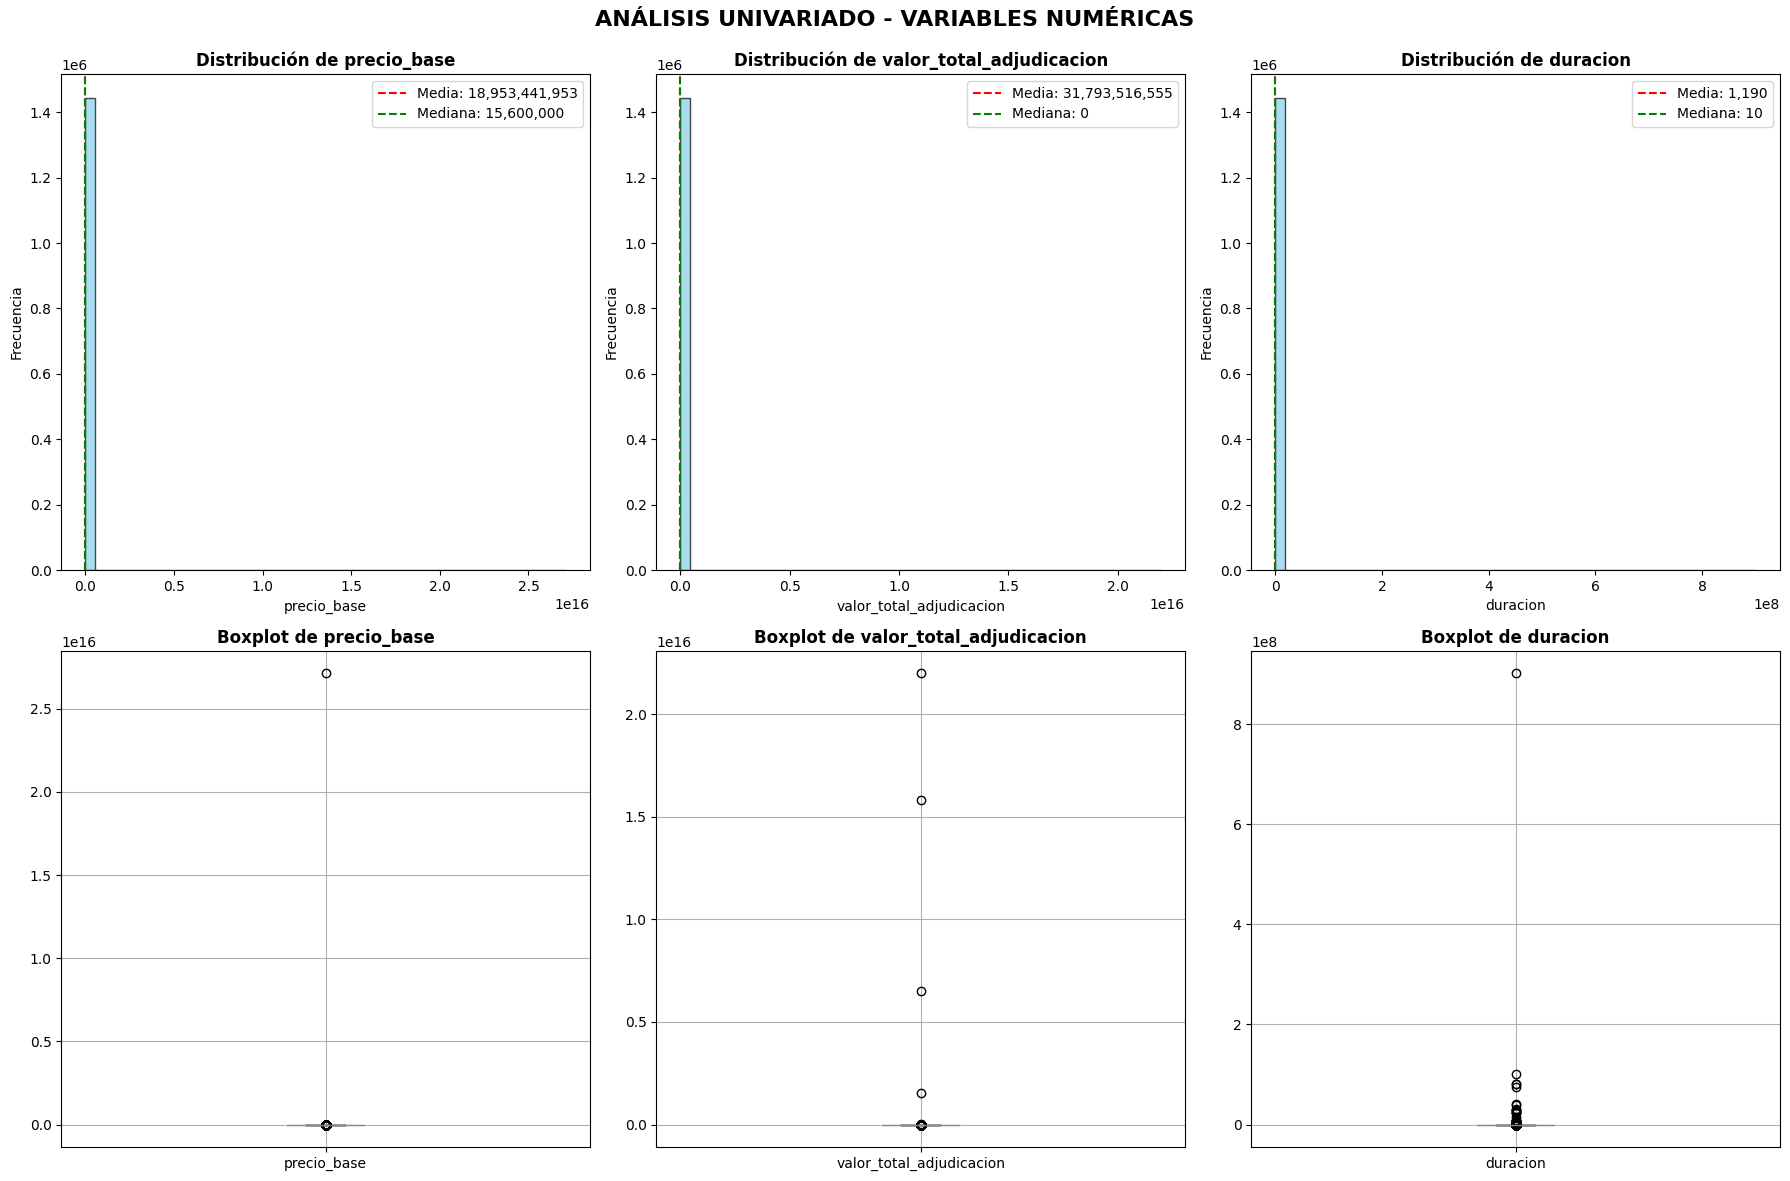

In [35]:
# VISUALIZACIONES PARA VARIABLES NUMÉRICAS
import matplotlib.pyplot as plt
import seaborn as sns

print("2. VISUALIZACIONES - VARIABLES NUMÉRICAS")
print("-" * 50)

# Configuración de estilo
plt.style.use('default')
sns.set_palette("husl")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('ANÁLISIS UNIVARIADO - VARIABLES NUMÉRICAS', fontsize=16, fontweight='bold')

for i, var in enumerate(variables_numericas):
    if var in df_limpio.columns:
        row = i // 3
        col = i % 3

        # Histograma con curva de densidad
        axes[row, col].hist(df_limpio[var], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
        axes[row, col].set_title(f'Distribución de {var}', fontweight='bold')
        axes[row, col].set_xlabel(var)
        axes[row, col].set_ylabel('Frecuencia')

        # Añadir líneas de referencia
        media = df_limpio[var].mean()
        mediana = df_limpio[var].median()
        axes[row, col].axvline(media, color='red', linestyle='--', label=f'Media: {media:,.0f}')
        axes[row, col].axvline(mediana, color='green', linestyle='--', label=f'Mediana: {mediana:,.0f}')
        axes[row, col].legend()

# Boxplots en la segunda fila
for i, var in enumerate(variables_numericas):
    if var in df_limpio.columns:
        row = 1
        col = i % 3

        # Boxplot
        df_limpio.boxplot(column=var, ax=axes[row, col], vert=True)
        axes[row, col].set_title(f'Boxplot de {var}', fontweight='bold')

plt.tight_layout()
plt.show()

In [36]:
# ANÁLISIS DE VARIABLES CATEGÓRICAS
print("3. VARIABLES CATEGÓRICAS")
print("-" * 40)

for var in variables_categoricas[:4]:  # Analizamos solo las primeras 4 para no saturar
    if var in df_limpio.columns:
        print(f"\n📈 ANÁLISIS DE: {var.upper()}")
        print("-" * 30)

        # Frecuencias
        frecuencias = df_limpio[var].value_counts()
        frecuencias_relativas = df_limpio[var].value_counts(normalize=True) * 100
        frecuencias_acumuladas = frecuencias_relativas.cumsum()

        # Crear tabla de frecuencias
        tabla_frecuencias = pd.DataFrame({
            'Frecuencia_Absoluta': frecuencias,
            'Frecuencia_Relativa_%': frecuencias_relativas,
            'Frecuencia_Acumulada_%': frecuencias_acumuladas
        })

        print(f"Total categorías: {len(frecuencias)}")
        print(f"Moda: {df_limpio[var].mode()[0] if not df_limpio[var].mode().empty else 'N/A'}")
        print(f"Proporción de la moda: {frecuencias_relativas.iloc[0]:.2f}%")
        print("\nTop 10 categorías:")
        display(tabla_frecuencias.head(10))

3. VARIABLES CATEGÓRICAS
----------------------------------------

📈 ANÁLISIS DE: ENTIDAD
------------------------------
Total categorías: 10237
Moda: UNIVERSIDAD NACIONAL DE COLOMBIA
Proporción de la moda: 1.73%

Top 10 categorías:


,Frecuencia_Absoluta,Frecuencia_Relativa_%,Frecuencia_Acumulada_%
entidad,,,
UNIVERSIDAD NACIONAL DE COLOMBIA,24917,1.725135,1.725135
INSTITUTO TECNOLOGICO METROPOLITANO,19796,1.370581,3.095716
(Secretaría Distrital de Integración Social),11256,0.779312,3.875028
SUBRED INTEGRADA DE SERVICIOS DE SALUD NORTE E.S.E. (OFICIAL),11252,0.779035,4.654063
AGENCIA NACIONAL DE TIERRAS - ANT,10388,0.719216,5.373278
LA CORPORACION COLOMBIANA DE INVESTIGACION AGROPECUARIA - AGROSAVIA,9683,0.670405,6.043683
UNIVERSIDAD DE ANTIOQUIA,9519,0.659050,6.702734
ALCALDÍA DEL DISTRITO TURÍSTICO Y CULTURAL DE CARTAGENA DE INDIAS,7907,0.547443,7.250177
INSTITUTO GEOGRÁFICO AGUSTÍN CODAZZI *,6470,0.447952,7.698129



📈 ANÁLISIS DE: DEPARTAMENTO_ENTIDAD
------------------------------
Total categorías: 34
Moda: Distrito Capital de Bogotá
Proporción de la moda: 22.48%

Top 10 categorías:


,Frecuencia_Absoluta,Frecuencia_Relativa_%,Frecuencia_Acumulada_%
departamento_entidad,,,
Distrito Capital de Bogotá,324647,22.477016,22.477016
Antioquia,189503,13.120287,35.597303
Valle del Cauca,117402,8.128357,43.725659
Cundinamarca,88754,6.144905,49.870565
Santander,66731,4.620137,54.490702
Nariño,52887,3.661645,58.152347
Magdalena,52811,3.656383,61.808729
Boyacá,48632,3.367049,65.175778
Bolívar,45325,3.138088,68.313866



📈 ANÁLISIS DE: MODALIDAD_DE_CONTRATACION
------------------------------
Total categorías: 16
Moda: Contratación régimen especial
Proporción de la moda: 48.05%

Top 10 categorías:


,Frecuencia_Absoluta,Frecuencia_Relativa_%,Frecuencia_Acumulada_%
modalidad_de_contratacion,,,
Contratación régimen especial,694059,48.053347,48.053347
Contratación directa,624925,43.266837,91.320185
Mínima cuantía,41110,2.846261,94.166446
Solicitud de información a los Proveedores,24856,1.720911,95.887357
Selección Abreviada de Menor Cuantía,24063,1.666008,97.553365
Selección abreviada subasta inversa,11216,0.776543,98.329907
Contratación Directa (con ofertas),7768,0.537819,98.867727
Contratación régimen especial (con ofertas),7033,0.486932,99.354658
Concurso de méritos abierto,3883,0.268840,99.623499



📈 ANÁLISIS DE: TIPO_DE_CONTRATO
------------------------------
Total categorías: 23
Moda: Prestación de servicios
Proporción de la moda: 66.62%

Top 10 categorías:


,Frecuencia_Absoluta,Frecuencia_Relativa_%,Frecuencia_Acumulada_%
tipo_de_contrato,,,
Prestación de servicios,962241,66.620994,66.620994
Decreto 092 de 2017,245913,17.025848,83.646842
Suministros,92105,6.376913,90.023755
Otro,43920,3.040812,93.064567
Compraventa,37586,2.602276,95.666843
No Especificado,25445,1.761691,97.428534
Obra,17220,1.192231,98.620765
Arrendamiento de inmuebles,5274,0.365147,98.985911
Seguros,4502,0.311697,99.297608


4. VISUALIZACIONES - VARIABLES CATEGÓRICAS
--------------------------------------------------


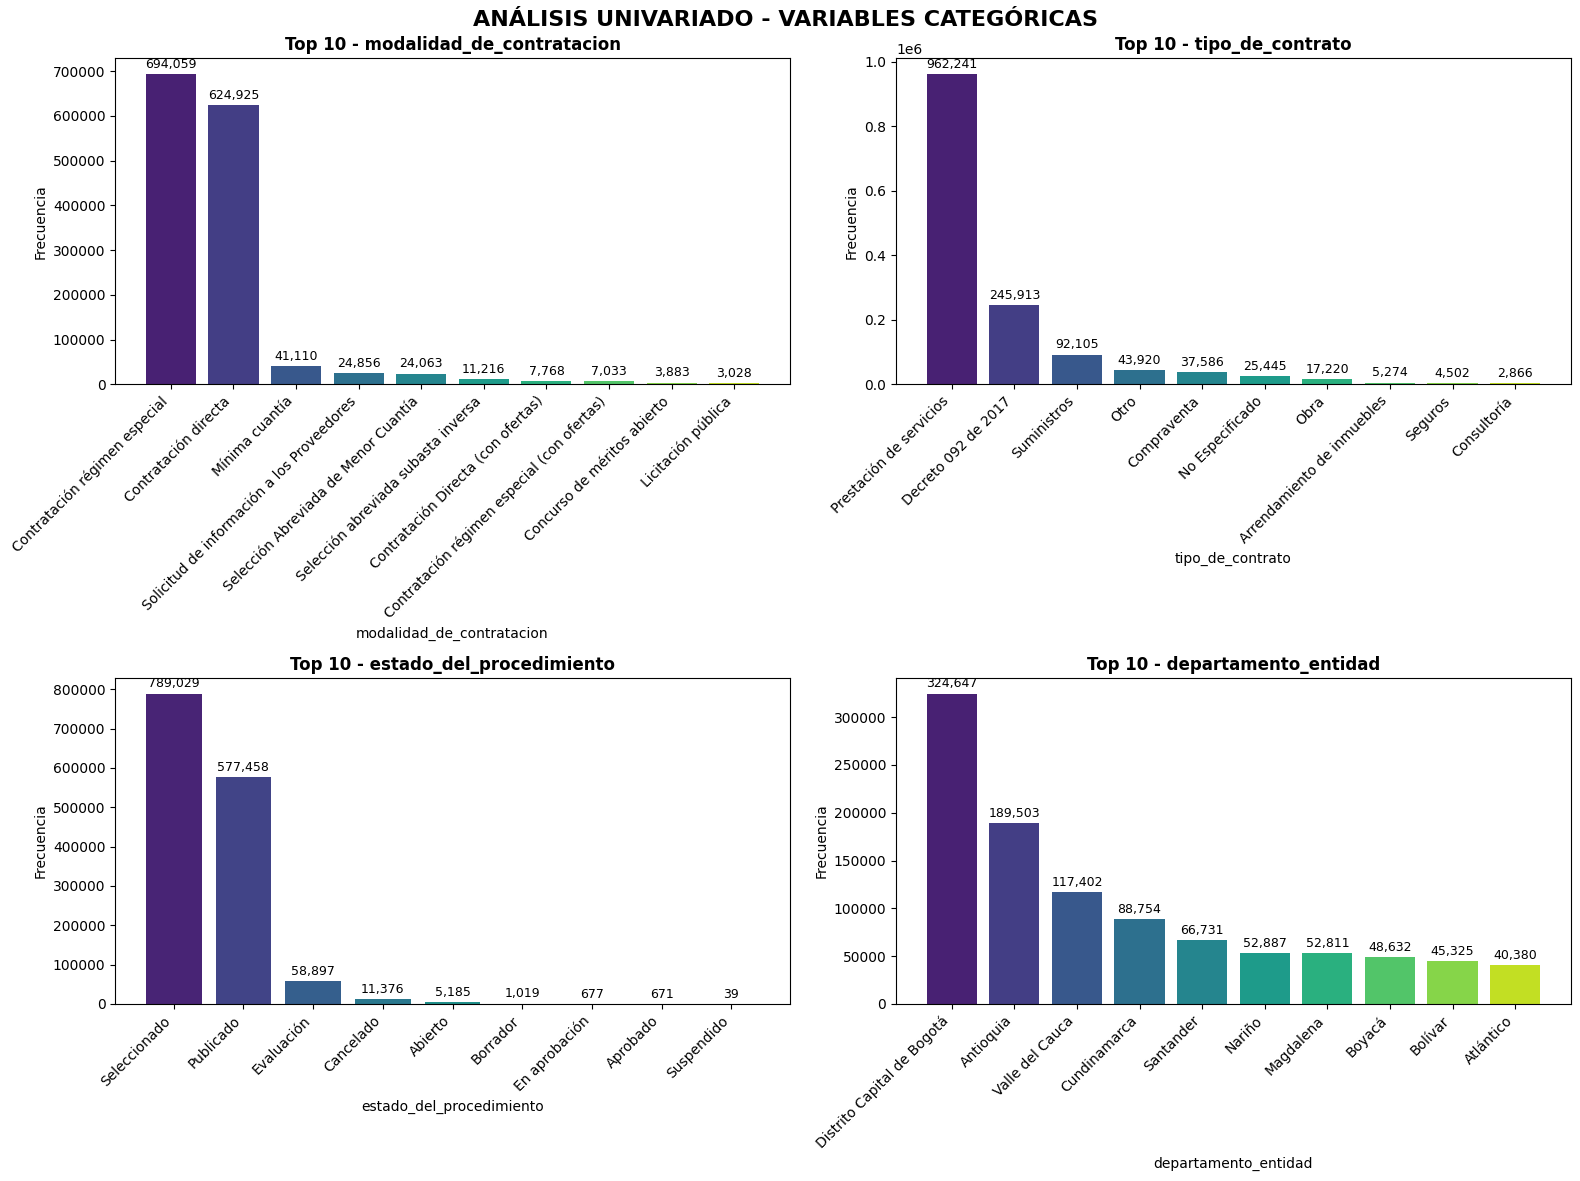

In [37]:
# VISUALIZACIONES PARA VARIABLES CATEGÓRICAS
print("4. VISUALIZACIONES - VARIABLES CATEGÓRICAS")
print("-" * 50)

# Analizamos las principales variables categóricas
variables_cat_principales = ['modalidad_de_contratacion', 'tipo_de_contrato',
                            'estado_del_procedimiento', 'departamento_entidad']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('ANÁLISIS UNIVARIADO - VARIABLES CATEGÓRICAS', fontsize=16, fontweight='bold')

for i, var in enumerate(variables_cat_principales):
    if var in df_limpio.columns:
        row = i // 2
        col = i % 2

        # Top 10 categorías
        top_categorias = df_limpio[var].value_counts().head(10)

        # Gráfico de barras
        bars = axes[row, col].bar(range(len(top_categorias)), top_categorias.values,
                                 color=sns.color_palette("viridis", len(top_categorias)))
        axes[row, col].set_title(f'Top 10 - {var}', fontweight='bold')
        axes[row, col].set_xlabel(var)
        axes[row, col].set_ylabel('Frecuencia')

        # Rotar etiquetas y añadir valores
        axes[row, col].set_xticks(range(len(top_categorias)))
        axes[row, col].set_xticklabels(top_categorias.index, rotation=45, ha='right')

        # Añadir valores en las barras
        for bar, valor in zip(bars, top_categorias.values):
            axes[row, col].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01*max(top_categorias.values),
                               f'{valor:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [38]:
# ANÁLISIS DE VARIABLES TEMPORALES
print("5. VARIABLES TEMPORALES")
print("-" * 40)

for var in variables_temporales:
    if var in df_limpio.columns:
        print(f"\n📅 ANÁLISIS DE: {var.upper()}")
        print("-" * 30)

        data_temp = df_limpio[var].dropna()

        if len(data_temp) > 0:
            stats_temp = {
                'Total registros': len(data_temp),
                'Registros nulos': df_limpio[var].isnull().sum(),
                'Fecha mínima': data_temp.min(),
                'Fecha máxima': data_temp.max(),
                'Rango temporal (días)': (data_temp.max() - data_temp.min()).days,
                'Moda': data_temp.mode()[0] if not data_temp.mode().empty else 'N/A'
            }

            for stat, value in stats_temp.items():
                print(f"{stat}: {value}")

            # Conteo por mes
            if var == 'fecha_de_publicacion_del':
                conteo_mensual = data_temp.dt.to_period('M').value_counts().sort_index()
                print(f"\n📊 CONTEOS MENSUALES (primeros 6 meses):")
                display(conteo_mensual.head(6))

5. VARIABLES TEMPORALES
----------------------------------------

📅 ANÁLISIS DE: FECHA_DE_PUBLICACION_DEL
------------------------------
Total registros: 1444351
Registros nulos: 0
Fecha mínima: 2025-01-01 00:00:00
Fecha máxima: 2025-10-06 00:00:00
Rango temporal (días): 278
Moda: 2025-02-12 00:00:00

📊 CONTEOS MENSUALES (primeros 6 meses):


,count
fecha_de_publicacion_del,
2025-01,218826
2025-02,217970
2025-03,157510
2025-04,124942
2025-05,136429
2025-06,115391



📅 ANÁLISIS DE: FECHA_ADJUDICACION
------------------------------
Total registros: 57079
Registros nulos: 1387272
Fecha mínima: 2025-01-01 00:00:00
Fecha máxima: 2025-10-05 00:00:00
Rango temporal (días): 277
Moda: 2025-04-11 00:00:00


6. VISUALIZACIONES - VARIABLES TEMPORALES
--------------------------------------------------


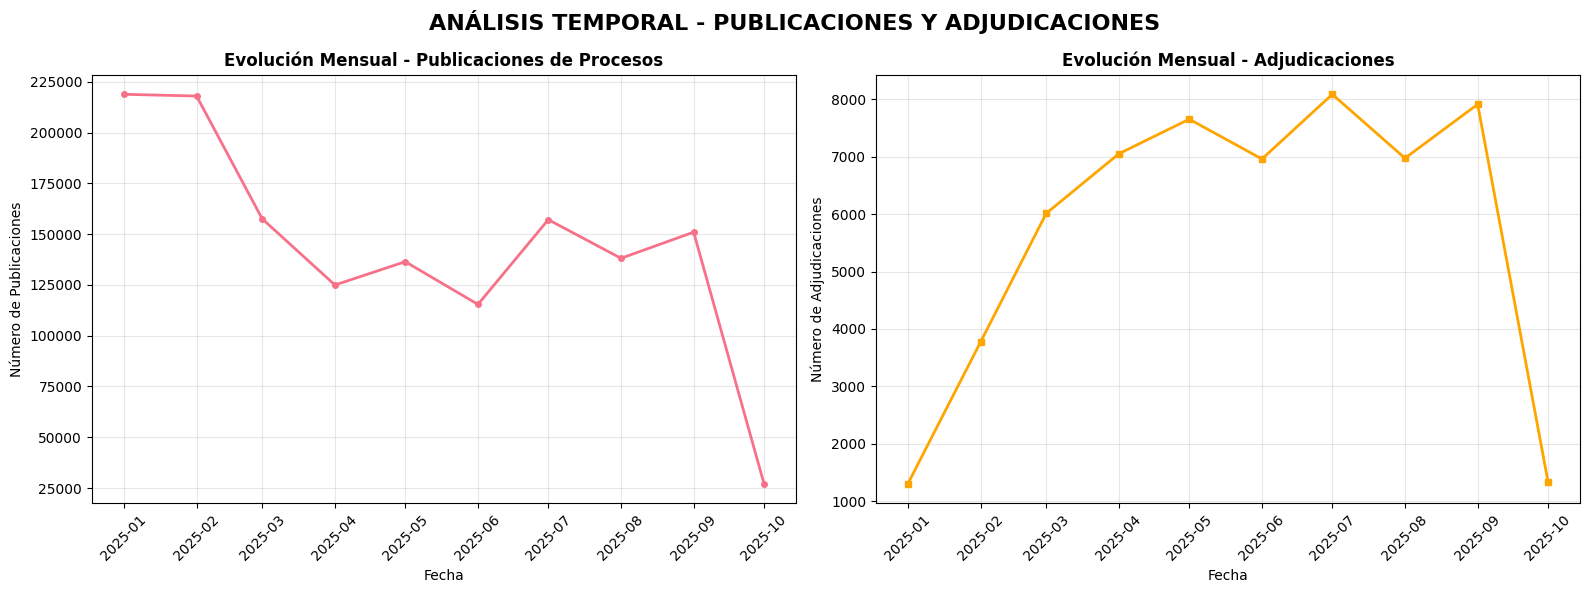

In [39]:
# VISUALIZACIONES TEMPORALES
print("6. VISUALIZACIONES - VARIABLES TEMPORALES")
print("-" * 50)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('ANÁLISIS TEMPORAL - PUBLICACIONES Y ADJUDICACIONES', fontsize=16, fontweight='bold')

# Serie temporal de publicaciones
if 'fecha_de_publicacion_del' in df_limpio.columns:
    publicaciones_mensuales = df_limpio['fecha_de_publicacion_del'].dt.to_period('M').value_counts().sort_index()
    publicaciones_mensuales.index = publicaciones_mensuales.index.to_timestamp()

    axes[0].plot(publicaciones_mensuales.index, publicaciones_mensuales.values,
                marker='o', linewidth=2, markersize=4)
    axes[0].set_title('Evolución Mensual - Publicaciones de Procesos', fontweight='bold')
    axes[0].set_xlabel('Fecha')
    axes[0].set_ylabel('Número de Publicaciones')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, alpha=0.3)

# Serie temporal de adjudicaciones (si hay datos)
if 'fecha_adjudicacion' in df_limpio.columns:
    adjudicaciones_mensuales = df_limpio['fecha_adjudicacion'].dropna().dt.to_period('M').value_counts().sort_index()
    if len(adjudicaciones_mensuales) > 0:
        adjudicaciones_mensuales.index = adjudicaciones_mensuales.index.to_timestamp()

        axes[1].plot(adjudicaciones_mensuales.index, adjudicaciones_mensuales.values,
                    marker='s', linewidth=2, markersize=4, color='orange')
        axes[1].set_title('Evolución Mensual - Adjudicaciones', fontweight='bold')
        axes[1].set_xlabel('Fecha')
        axes[1].set_ylabel('Número de Adjudicaciones')
        axes[1].tick_params(axis='x', rotation=45)
        axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Analisis Bivariado

In [40]:
# ANÁLISIS BIVARIADO
print("ANÁLISIS BIVARIADO")
print("="*60)

# Configuración para visualizaciones
plt.style.use('default')
sns.set_palette("viridis")

ANÁLISIS BIVARIADO


1. RELACIONES NUMÉRICAS vs NUMÉRICAS
--------------------------------------------------
📊 MATRIZ DE CORRELACIÓN (Pearson):


,precio_base,valor_total_adjudicacion,duracion
precio_base,1.000000,-0.000001,-0.000001
valor_total_adjudicacion,-0.000001,1.000000,-0.000002
duracion,-0.000001,-0.000002,1.000000


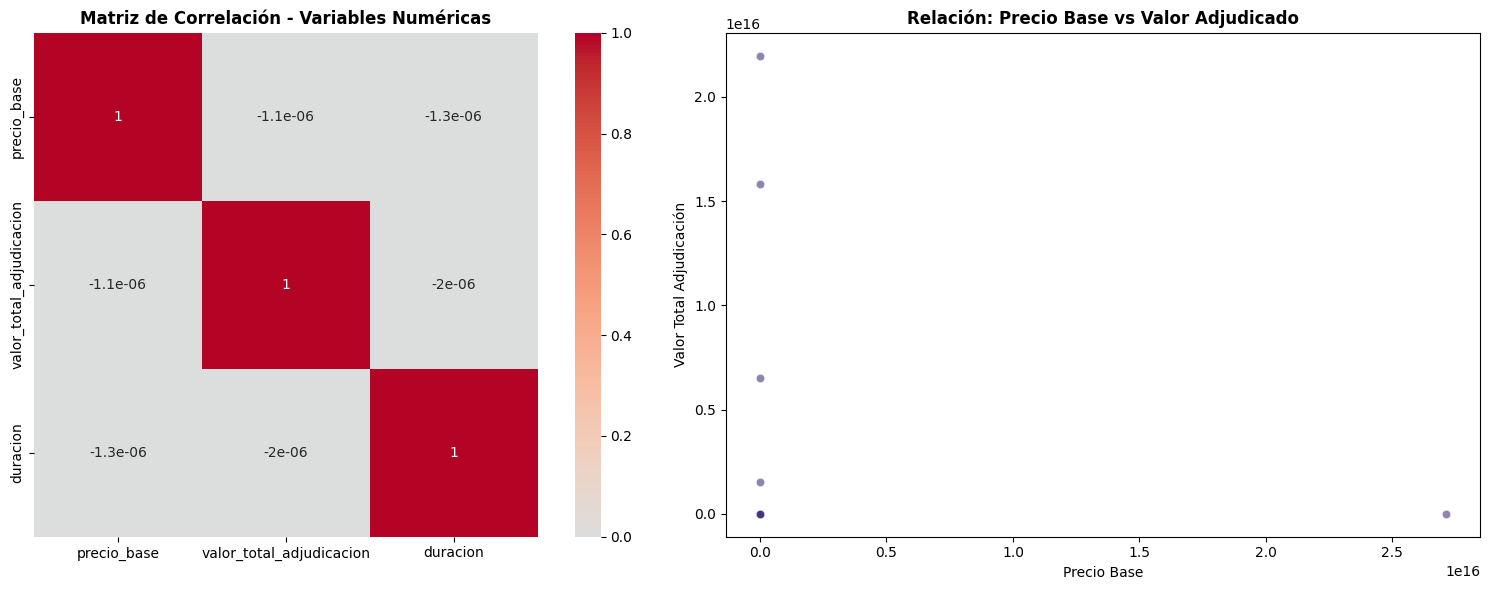


🔍 CORRELACIONES SIGNIFICATIVAS:


In [41]:
# 3.1 NUMÉRICAS vs NUMÉRICAS - MATRIZ DE CORRELACIÓN
print("1. RELACIONES NUMÉRICAS vs NUMÉRICAS")
print("-" * 50)

# Seleccionar variables numéricas para correlación
vars_corr = ['precio_base', 'valor_total_adjudicacion', 'duracion']
df_numericas = df_limpio[vars_corr]

# Matriz de correlación
correlation_matrix = df_numericas.corr(method='pearson')

print("📊 MATRIZ DE CORRELACIÓN (Pearson):")
display(correlation_matrix)

# Visualización de la matriz de correlación
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap de correlación
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, ax=axes[0])
axes[0].set_title('Matriz de Correlación - Variables Numéricas', fontweight='bold')

# Scatter matrix
if len(vars_corr) > 1:
    # Scatter plot de las dos variables más correlacionadas
    sns.scatterplot(data=df_limpio, x='precio_base', y='valor_total_adjudicacion',
                   alpha=0.6, ax=axes[1])
    axes[1].set_title('Relación: Precio Base vs Valor Adjudicado', fontweight='bold')
    axes[1].set_xlabel('Precio Base')
    axes[1].set_ylabel('Valor Total Adjudicación')

plt.tight_layout()
plt.show()

# Análisis de correlaciones significativas
print("\n🔍 CORRELACIONES SIGNIFICATIVAS:")
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.3:  # Umbral para correlación moderada
            print(f"  {correlation_matrix.columns[i]} vs {correlation_matrix.columns[j]}: {corr_val:.3f}")


2. RELACIONES NUMÉRICAS vs CATEGÓRICAS
--------------------------------------------------


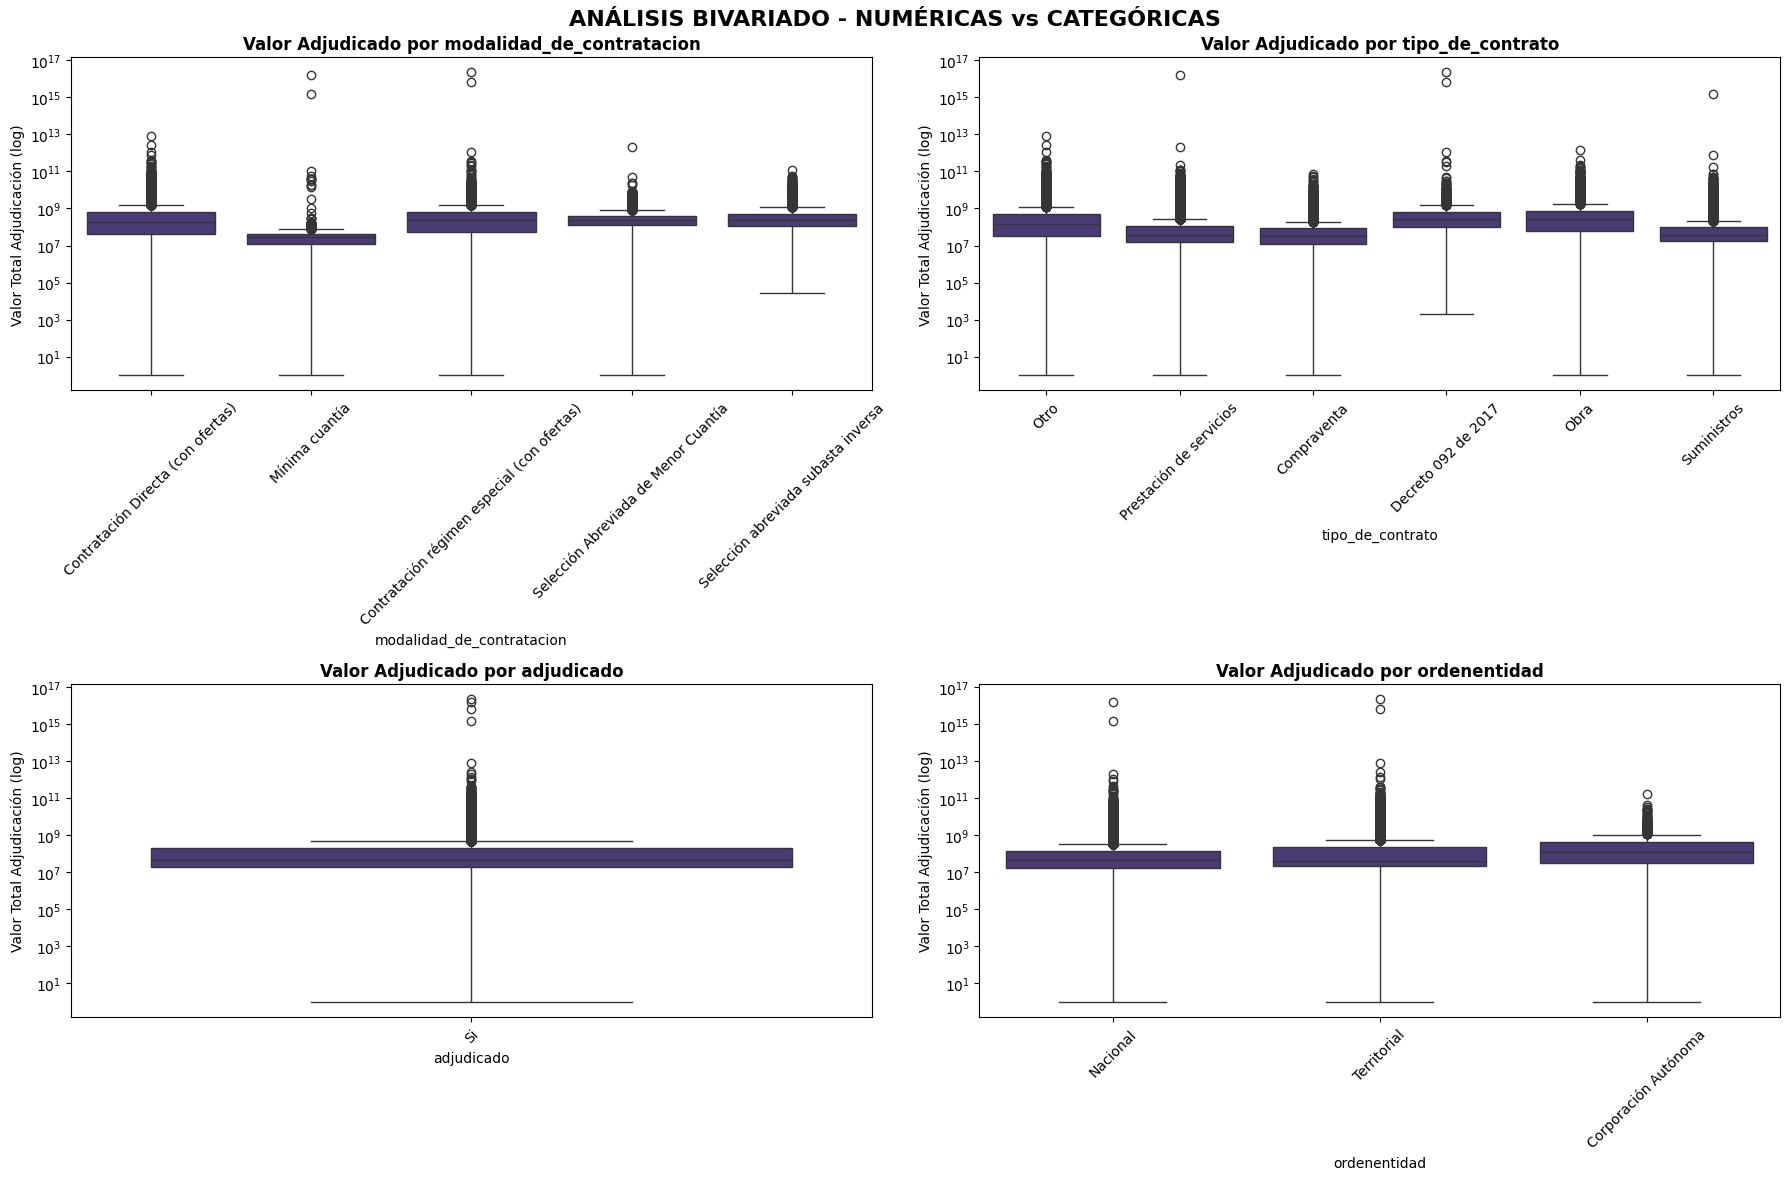

In [42]:
# 3.2 NUMÉRICAS vs CATEGÓRICAS
print("\n2. RELACIONES NUMÉRICAS vs CATEGÓRICAS")
print("-" * 50)

# Variables categóricas clave para análisis
cat_vars_analysis = ['modalidad_de_contratacion', 'tipo_de_contrato', 'adjudicado', 'ordenentidad']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('ANÁLISIS BIVARIADO - NUMÉRICAS vs CATEGÓRICAS', fontsize=16, fontweight='bold')

for i, cat_var in enumerate(cat_vars_analysis):
    if cat_var in df_limpio.columns:
        row = i // 2
        col = i % 2

        # Boxplot para comparar distribuciones
        # Tomar top 8 categorías para evitar saturación
        top_categories = df_limpio[cat_var].value_counts().head(8).index
        df_filtered = df_limpio[df_limpio[cat_var].isin(top_categories)]

        # Usar valor_total_adjudicacion como variable numérica (excluyendo ceros para mejor visualización)
        data_plot = df_filtered[df_filtered['valor_total_adjudicacion'] > 0]

        if len(data_plot) > 0:
            sns.boxplot(data=data_plot, x=cat_var, y='valor_total_adjudicacion', ax=axes[row, col])
            axes[row, col].set_title(f'Valor Adjudicado por {cat_var}', fontweight='bold')
            axes[row, col].set_xlabel(cat_var)
            axes[row, col].set_ylabel('Valor Total Adjudicación (log)')
            axes[row, col].set_yscale('log')  # Escala logarítmica para mejor visualización
            axes[row, col].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [43]:
# ANÁLISIS ESTADÍSTICO NUMÉRICAS vs CATEGÓRICAS
print("\n3. ANÁLISIS ESTADÍSTICO - ANOVA Y TEST K-W")
print("-" * 50)

from scipy import stats

for cat_var in ['modalidad_de_contratacion', 'adjudicado']:
    if cat_var in df_limpio.columns:
        print(f"\n📈 ANÁLISIS: Valor Adjudicado vs {cat_var}")
        print("-" * 40)

        # Preparar datos para ANOVA
        grupos = []
        categorias = df_limpio[cat_var].value_counts().head(5).index  # Top 5 categorías

        for categoria in categorias:
            grupo = df_limpio[df_limpio[cat_var] == categoria]['valor_total_adjudicacion']
            # Filtrar valores positivos
            grupo = grupo[grupo > 0]
            if len(grupo) > 0:
                grupos.append(grupo)
                print(f"  {categoria}: n={len(grupo)}, media={grupo.mean():,.0f}, mediana={grupo.median():,.0f}")

        # ANOVA si hay suficientes grupos
        if len(grupos) >= 2:
            # Test de normalidad (Shapiro-Wilk en muestra reducida por eficiencia)
            normalidad = all(stats.shapiro(grupo.sample(min(5000, len(grupo))))[1] > 0.05 for grupo in grupos if len(grupo) > 3)

            if normalidad:
                # ANOVA paramétrico
                f_stat, p_value = stats.f_oneway(*grupos)
                print(f"  ANOVA: F={f_stat:.3f}, p-value={p_value:.4f}")
            else:
                # Kruskal-Wallis no paramétrico
                h_stat, p_value = stats.kruskal(*grupos)
                print(f"  Kruskal-Wallis: H={h_stat:.3f}, p-value={p_value:.4f}")

            # Interpretación
            if p_value < 0.05:
                print("  ✅ Diferencias SIGNIFICATIVAS entre grupos")
            else:
                print("  ❌ No hay diferencias significativas entre grupos")


3. ANÁLISIS ESTADÍSTICO - ANOVA Y TEST K-W
--------------------------------------------------

📈 ANÁLISIS: Valor Adjudicado vs modalidad_de_contratacion
----------------------------------------
  Mínima cuantía: n=32992, media=526,644,942,767, mediana=27,123,184
  Selección Abreviada de Menor Cuantía: n=6064, media=739,373,848, mediana=236,734,355
  Kruskal-Wallis: H=13509.246, p-value=0.0000
  ✅ Diferencias SIGNIFICATIVAS entre grupos

📈 ANÁLISIS: Valor Adjudicado vs adjudicado
----------------------------------------
  Si: n=58607, media=783,541,171,349, mediana=43,100,000



4. RELACIONES CATEGÓRICAS vs CATEGÓRICAS
--------------------------------------------------


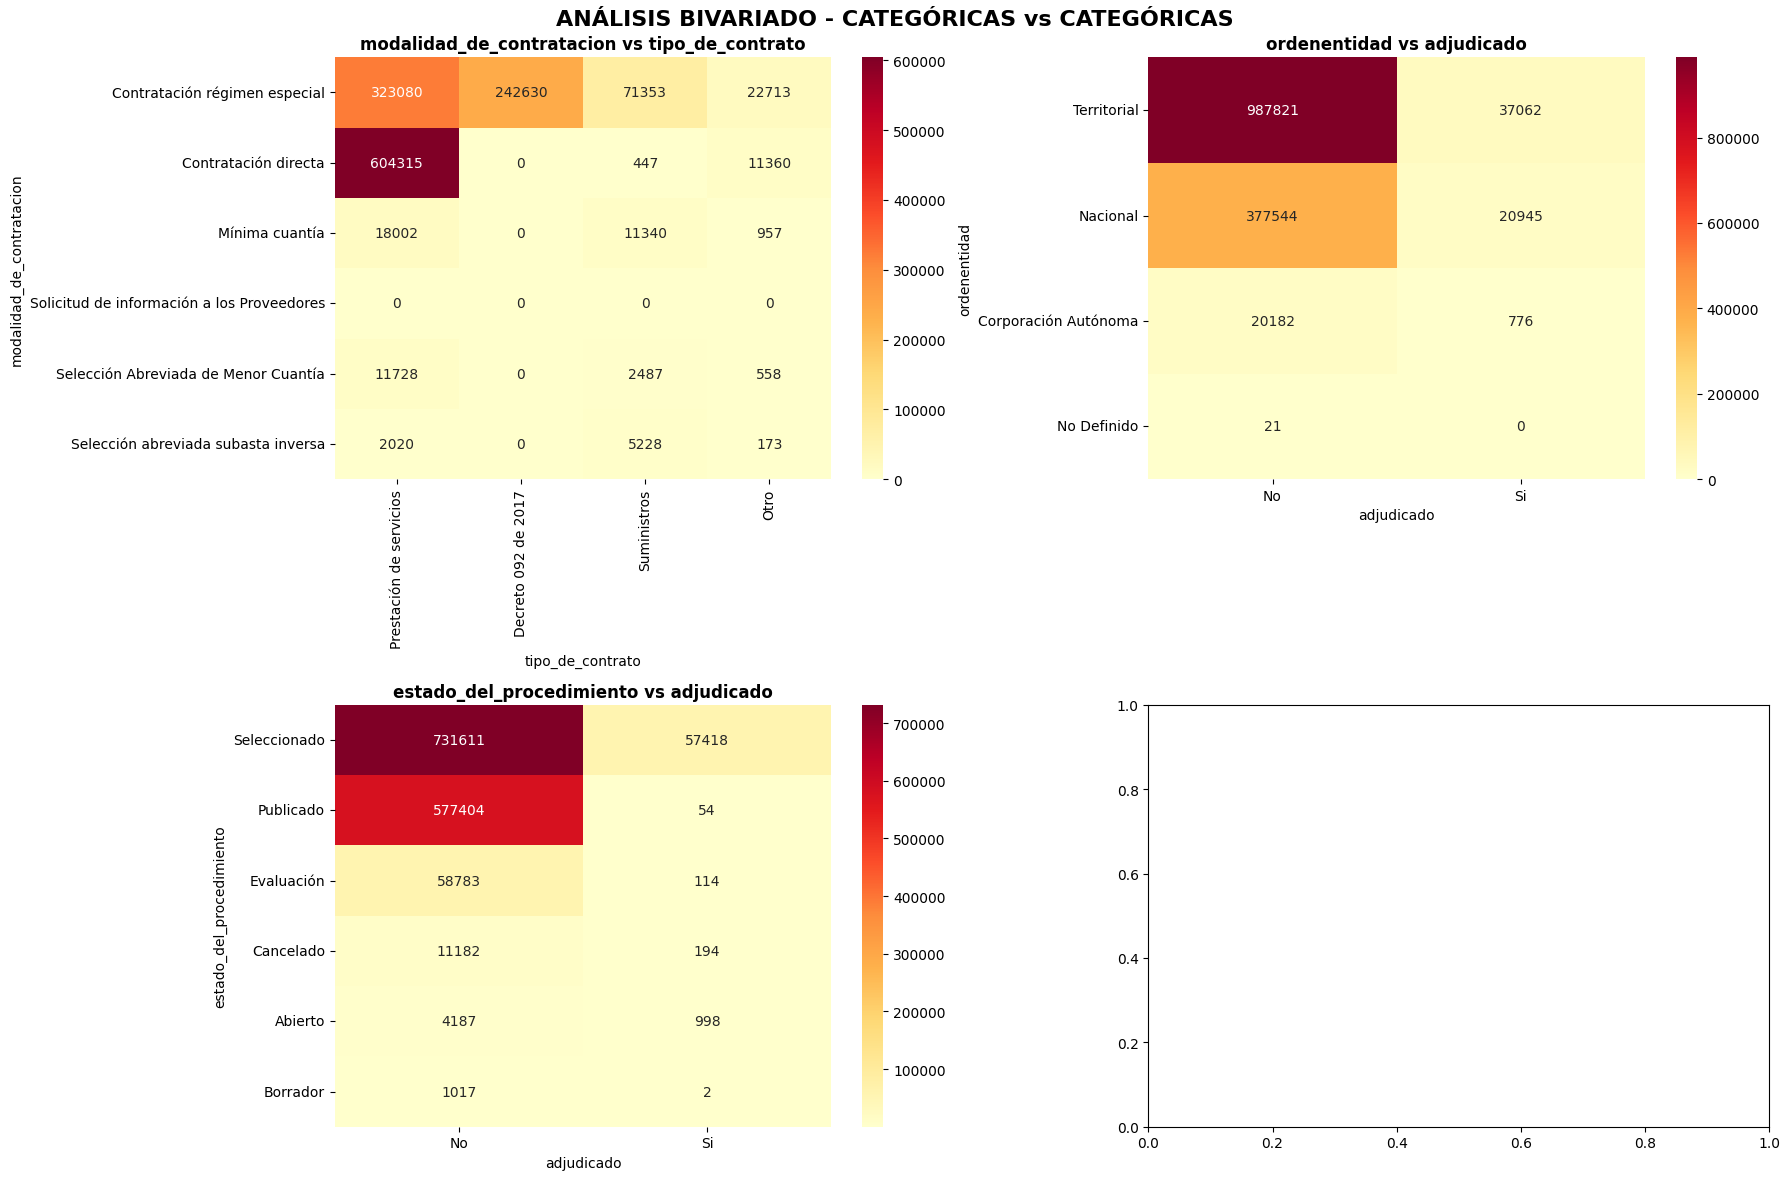

In [44]:
# 3.3 CATEGÓRICAS vs CATEGÓRICAS
print("\n4. RELACIONES CATEGÓRICAS vs CATEGÓRICAS")
print("-" * 50)

# Seleccionar pares de variables categóricas para análisis
categorical_pairs = [
    ('modalidad_de_contratacion', 'tipo_de_contrato'),
    ('ordenentidad', 'adjudicado'),
    ('estado_del_procedimiento', 'adjudicado')
]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('ANÁLISIS BIVARIADO - CATEGÓRICAS vs CATEGÓRICAS', fontsize=16, fontweight='bold')

for i, (cat_var1, cat_var2) in enumerate(categorical_pairs):
    if i >= 4:  # Limitar a 4 gráficos
        break

    if cat_var1 in df_limpio.columns and cat_var2 in df_limpio.columns:
        row = i // 2
        col = i % 2

        # Crear tabla de contingencia
        contingency_table = pd.crosstab(df_limpio[cat_var1], df_limpio[cat_var2])

        # Tomar top categorías para visualización
        top_cat1 = df_limpio[cat_var1].value_counts().head(6).index
        top_cat2 = df_limpio[cat_var2].value_counts().head(4).index

        contingency_filtered = contingency_table.loc[top_cat1, top_cat2]

        # Heatmap de la tabla de contingencia
        sns.heatmap(contingency_filtered, annot=True, fmt='d', cmap='YlOrRd',
                   ax=axes[row, col])
        axes[row, col].set_title(f'{cat_var1} vs {cat_var2}', fontweight='bold')
        axes[row, col].set_xlabel(cat_var2)
        axes[row, col].set_ylabel(cat_var1)

plt.tight_layout()
plt.show()

In [45]:
# TEST CHI-CUADRADO PARA ASOCIACIÓN ENTRE CATEGÓRICAS
print("\n5. TEST CHI-CUADRADO - ASOCIACIÓN ENTRE VARIABLES CATEGÓRICAS")
print("-" * 60)

from scipy.stats import chi2_contingency

for cat_var1, cat_var2 in categorical_pairs:
    if cat_var1 in df_limpio.columns and cat_var2 in df_limpio.columns:
        print(f"\n🔍 TEST CHI-CUADRADO: {cat_var1} vs {cat_var2}")
        print("-" * 40)

        # Crear tabla de contingencia
        contingency_table = pd.crosstab(df_limpio[cat_var1], df_limpio[cat_var2])

        # Aplicar test chi-cuadrado
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)

        print(f"  Chi-cuadrado: {chi2:.3f}")
        print(f"  p-value: {p_value:.4f}")
        print(f"  Grados de libertad: {dof}")

        # Interpretación
        if p_value < 0.05:
            print("  ✅ Asociación SIGNIFICATIVA entre variables")
            # Calcular V de Cramer para fuerza de asociación
            n = contingency_table.sum().sum()
            cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))
            print(f"  V de Cramer: {cramers_v:.3f}")

            if cramers_v < 0.1:
                print("  Fuerza de asociación: Débil")
            elif cramers_v < 0.3:
                print("  Fuerza de asociación: Moderada")
            else:
                print("  Fuerza de asociación: Fuerte")
        else:
            print("  ❌ No hay asociación significativa entre variables")


5. TEST CHI-CUADRADO - ASOCIACIÓN ENTRE VARIABLES CATEGÓRICAS
------------------------------------------------------------

🔍 TEST CHI-CUADRADO: modalidad_de_contratacion vs tipo_de_contrato
----------------------------------------
  Chi-cuadrado: 6596908.825
  p-value: 0.0000
  Grados de libertad: 330
  ✅ Asociación SIGNIFICATIVA entre variables
  V de Cramer: 0.552
  Fuerza de asociación: Fuerte

🔍 TEST CHI-CUADRADO: ordenentidad vs adjudicado
----------------------------------------
  Chi-cuadrado: 1984.599
  p-value: 0.0000
  Grados de libertad: 3
  ✅ Asociación SIGNIFICATIVA entre variables
  V de Cramer: 0.037
  Fuerza de asociación: Débil

🔍 TEST CHI-CUADRADO: estado_del_procedimiento vs adjudicado
----------------------------------------
  Chi-cuadrado: 50755.242
  p-value: 0.0000
  Grados de libertad: 8
  ✅ Asociación SIGNIFICATIVA entre variables
  V de Cramer: 0.187
  Fuerza de asociación: Moderada


## Analisis multivariado

In [46]:
# ANÁLISIS MULTIVARIADO
print("ANÁLISIS MULTIVARIADO")
print("="*60)

# Preparar datos para análisis multivariado
print("Preparando datos para análisis multivariado...")

ANÁLISIS MULTIVARIADO
Preparando datos para análisis multivariado...


1. ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)
--------------------------------------------------
📊 RESULTADOS DEL PCA:
Varianza explicada por cada componente: [0.37940186 0.33332852 0.28726962]
Varianza acumulada: [0.37940186 0.71273038 1.        ]


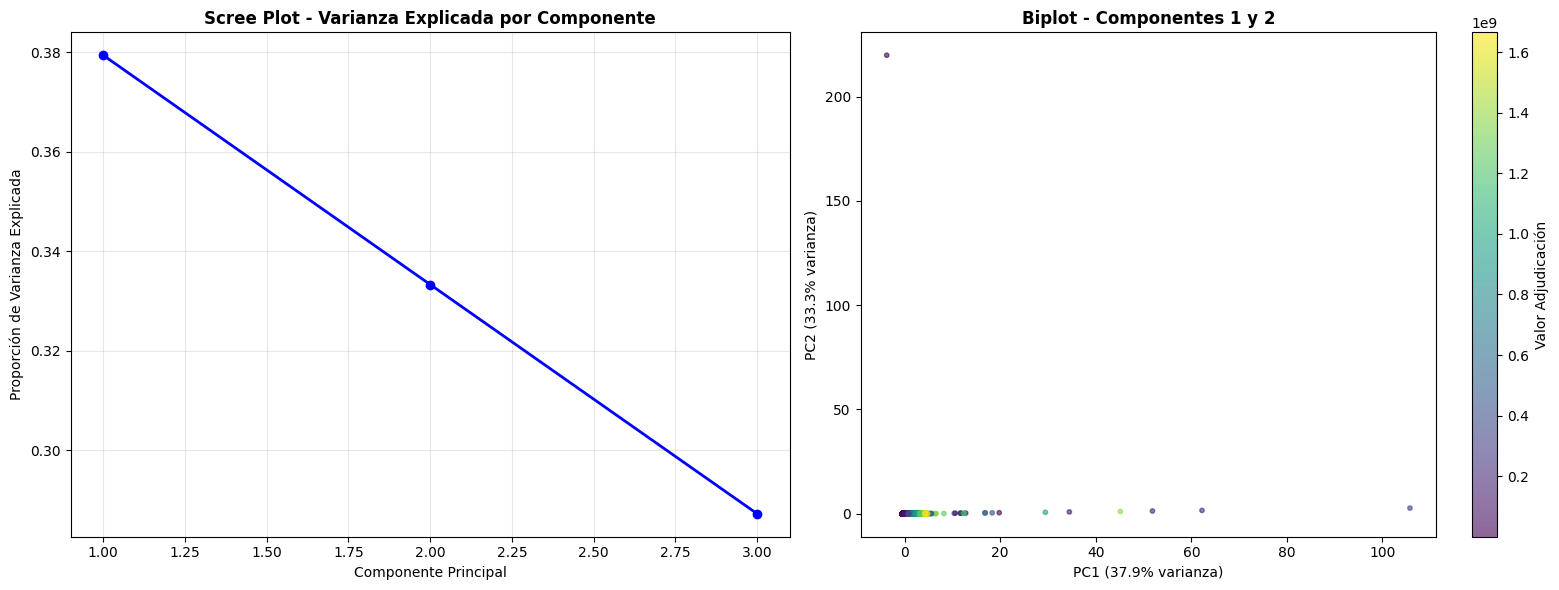


🔍 INTERPRETACIÓN DE COMPONENTES:
Matriz de cargas (loadings):


,PC1,PC2,PC3
precio_base,0.754250,0.018324,-0.656347
valor_total_adjudicacion,0.754374,0.002850,0.656454
duracion,-0.015974,0.999831,0.010157


In [47]:
# 4.1 ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)
print("1. ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)")
print("-" * 50)

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Preparar datos numéricos para PCA
vars_pca = ['precio_base', 'valor_total_adjudicacion', 'duracion']
df_pca = df_limpio[vars_pca].copy()

# Filtrar y escalar datos
df_pca = df_pca[(df_pca > 0).all(axis=1)]  # Solo registros con valores positivos
df_pca = df_pca[df_pca['valor_total_adjudicacion'] < df_pca['valor_total_adjudicacion'].quantile(0.95)]  # Remover outliers

if len(df_pca) > 0:
    # Estandarizar datos
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_pca)

    # Aplicar PCA
    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)

    # Resultados del PCA
    print("📊 RESULTADOS DEL PCA:")
    print(f"Varianza explicada por cada componente: {pca.explained_variance_ratio_}")
    print(f"Varianza acumulada: {np.cumsum(pca.explained_variance_ratio_)}")

    # Visualización del PCA
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Scree plot
    components = range(1, len(pca.explained_variance_ratio_) + 1)
    axes[0].plot(components, pca.explained_variance_ratio_, 'bo-', linewidth=2)
    axes[0].set_title('Scree Plot - Varianza Explicada por Componente', fontweight='bold')
    axes[0].set_xlabel('Componente Principal')
    axes[0].set_ylabel('Proporción de Varianza Explicada')
    axes[0].grid(True, alpha=0.3)

    # Biplot (primeros dos componentes)
    if X_pca.shape[1] >= 2:
        scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, c=df_pca['valor_total_adjudicacion'],
                                 cmap='viridis', s=10)
        axes[1].set_title('Biplot - Componentes 1 y 2', fontweight='bold')
        axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
        axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
        plt.colorbar(scatter, ax=axes[1], label='Valor Adjudicación')

    plt.tight_layout()
    plt.show()

    # Interpretación de componentes
    print("\n🔍 INTERPRETACIÓN DE COMPONENTES:")
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
    loading_matrix = pd.DataFrame(loadings, columns=[f'PC{i+1}' for i in range(len(vars_pca))],
                                 index=vars_pca)
    print("Matriz de cargas (loadings):")
    display(loading_matrix)
else:
    print("No hay suficientes datos para realizar PCA")

In [49]:
!pip install factor_analyzer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 4.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=295f967833ff62f734ac566fd6b0cc13337ed4c9541091bb7e8ff34f5481c8d9
  Stored in directory: /root/.cache/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor_analyzer


In [50]:
# 4.2 ANÁLISIS FACTORIAL
print("\n2. ANÁLISIS FACTORIAL")
print("-" * 50)

from sklearn.decomposition import FactorAnalysis
from factor_analyzer import FactorAnalyzer  # Si está disponible

try:
    # Usar FactorAnalyzer si está instalado, si no usar PCA como aproximación
    if len(df_pca) > 0:
        # Análisis factorial con FactorAnalyzer
        fa = FactorAnalyzer(n_factors=2, rotation='varimax')
        fa.fit(X_scaled)

        # Cargas factoriales
        loadings_fa = fa.loadings_

        print("📊 RESULTADOS DEL ANÁLISIS FACTORIAL:")
        loadings_df = pd.DataFrame(loadings_fa, columns=['Factor1', 'Factor2'], index=vars_pca)
        print("Cargas factoriales (rotación varimax):")
        display(loadings_df)

        # Comunalidades
        communalities = fa.get_communalities()
        print("\nComunalidades:")
        for var, comm in zip(vars_pca, communalities):
            print(f"  {var}: {comm:.3f}")

        # Varianza explicada
        variance_fa = fa.get_factor_variance()
        print(f"\nVarianza explicada por factores: {variance_fa[0]}")
        print(f"Varianza total explicada: {sum(variance_fa[0]):.3f}")

except ImportError:
    print("⚠️  FactorAnalyzer no está instalado. Usando PCA como aproximación.")
    print("Para análisis factorial completo: pip install factor-analyzer")


2. ANÁLISIS FACTORIAL
--------------------------------------------------
📊 RESULTADOS DEL ANÁLISIS FACTORIAL:
Cargas factoriales (rotación varimax):


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,Factor1,Factor2
precio_base,0.373058,0.010861
valor_total_adjudicacion,0.371465,-0.037165
duracion,-0.002355,0.044600



Comunalidades:
  precio_base: 0.139
  valor_total_adjudicacion: 0.139
  duracion: 0.002

Varianza explicada por factores: [0.27716451 0.00348829]
Varianza total explicada: 0.281



3. ANÁLISIS DE CORRESPONDENCIAS MÚLTIPLES (ACM)
--------------------------------------------------
📊 RESULTADOS DEL ACM (aproximación con PCA):
Varianza explicada: [0.66901305 0.28795135]


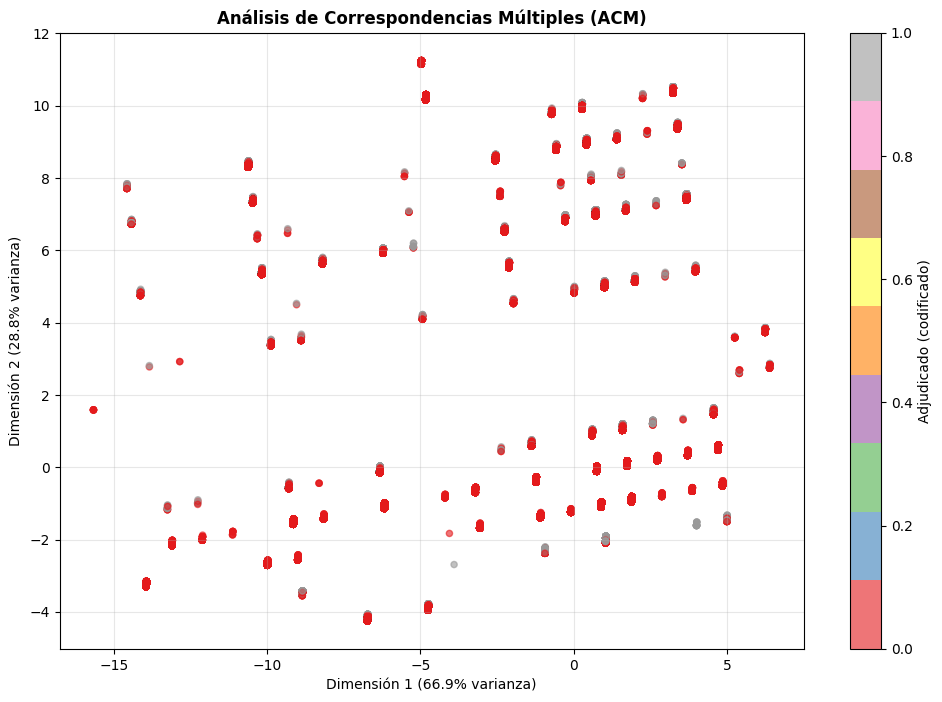


🔍 CONTRIBUCIÓN DE VARIABLES AL ACM:
  modalidad_de_contratacion: Dim1=-0.221, Dim2=0.975
  tipo_de_contrato: Dim1=0.995, Dim2=0.097
  ordenentidad: Dim1=-0.015, Dim2=-0.119
  adjudicado: Dim1=-0.050, Dim2=0.445


In [51]:
# 4.3 ANÁLISIS DE CORRESPONDENCIAS MÚLTIPLES (ACM)
print("\n3. ANÁLISIS DE CORRESPONDENCIAS MÚLTIPLES (ACM)")
print("-" * 50)

from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA as PCA_categorical

# Seleccionar variables categóricas para ACM
vars_acm = ['modalidad_de_contratacion', 'tipo_de_contrato', 'ordenentidad', 'adjudicado']
df_acm = df_limpio[vars_acm].copy()

# Codificar variables categóricas
label_encoders = {}
df_encoded = pd.DataFrame()

for var in vars_acm:
    le = LabelEncoder()
    df_encoded[var] = le.fit_transform(df_limpio[var].astype(str))
    label_encoders[var] = le

# Aplicar PCA a datos codificados (aproximación al ACM)
acm = PCA(n_components=2)
acm_result = acm.fit_transform(df_encoded)

# Resultados del ACM
print("📊 RESULTADOS DEL ACM (aproximación con PCA):")
print(f"Varianza explicada: {acm.explained_variance_ratio_}")

# Visualización ACM
plt.figure(figsize=(12, 8))
scatter = plt.scatter(acm_result[:, 0], acm_result[:, 1], alpha=0.6,
                     c=df_encoded['adjudicado'], cmap='Set1', s=20)
plt.title('Análisis de Correspondencias Múltiples (ACM)', fontweight='bold')
plt.xlabel(f'Dimensión 1 ({acm.explained_variance_ratio_[0]:.1%} varianza)')
plt.ylabel(f'Dimensión 2 ({acm.explained_variance_ratio_[1]:.1%} varianza)')
plt.colorbar(scatter, label='Adjudicado (codificado)')
plt.grid(True, alpha=0.3)
plt.show()

# Interpretación de variables en el ACM
print("\n🔍 CONTRIBUCIÓN DE VARIABLES AL ACM:")
for i, var in enumerate(vars_acm):
    correlation_with_dim1 = np.corrcoef(df_encoded[var], acm_result[:, 0])[0, 1]
    correlation_with_dim2 = np.corrcoef(df_encoded[var], acm_result[:, 1])[0, 1]
    print(f"  {var}: Dim1={correlation_with_dim1:.3f}, Dim2={correlation_with_dim2:.3f}")

## Analisis de segmentacion

In [52]:
  # ANÁLISIS DE SEGMENTACIÓN - CLUSTERING
print("ANÁLISIS DE SEGMENTACIÓN (CLUSTERING)")
print("-" * 50)

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch

ANÁLISIS DE SEGMENTACIÓN (CLUSTERING)
--------------------------------------------------


1. PREPARACIÓN DE DATOS PARA CLUSTERING
----------------------------------------
Datos para clustering: (48344, 3)

2. DETERMINACIÓN DEL NÚMERO ÓPTIMO DE CLÚSTERES
--------------------------------------------------


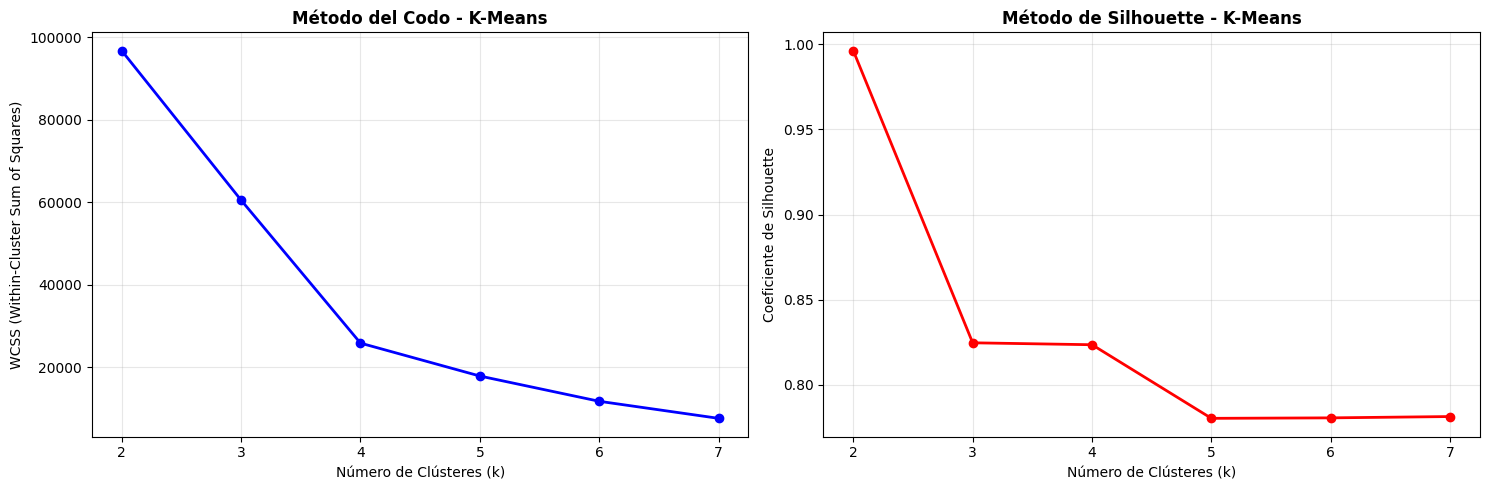

📊 NÚMERO ÓPTIMO DE CLÚSTERES SUGERIDO: 2


In [53]:
# 5.1 PREPARACIÓN DE DATOS PARA CLUSTERING
print("1. PREPARACIÓN DE DATOS PARA CLUSTERING")
print("-" * 40)

# Seleccionar variables para clustering
vars_cluster = ['precio_base', 'valor_total_adjudicacion', 'duracion']
df_cluster = df_limpio[vars_cluster].copy()

# Filtrar datos: solo registros con valores positivos y sin outliers extremos
df_cluster = df_cluster[(df_cluster > 0).all(axis=1)]
df_cluster = df_cluster[df_cluster['valor_total_adjudicacion'] < df_cluster['valor_total_adjudicacion'].quantile(0.95)]

print(f"Datos para clustering: {df_cluster.shape}")

if len(df_cluster) > 0:
    # Estandarizar datos
    scaler_cluster = StandardScaler()
    X_cluster = scaler_cluster.fit_transform(df_cluster)

    # 5.2 DETERMINACIÓN DEL NÚMERO ÓPTIMO DE CLÚSTERES
    print("\n2. DETERMINACIÓN DEL NÚMERO ÓPTIMO DE CLÚSTERES")
    print("-" * 50)

    # Método del codo y silhouette
    wcss = []  # Within-Cluster Sum of Squares
    silhouette_scores = []
    k_range = range(2, 8)

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X_cluster)
        wcss.append(kmeans.inertia_)

        if len(X_cluster) > k:  # Silhouette necesita al menos 2 muestras por cluster
            silhouette_scores.append(silhouette_score(X_cluster, kmeans.labels_))

    # Visualización métodos de selección de k
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Método del codo
    axes[0].plot(k_range, wcss, 'bo-', linewidth=2)
    axes[0].set_title('Método del Codo - K-Means', fontweight='bold')
    axes[0].set_xlabel('Número de Clústeres (k)')
    axes[0].set_ylabel('WCSS (Within-Cluster Sum of Squares)')
    axes[0].grid(True, alpha=0.3)

    # Método de silhouette
    axes[1].plot(list(k_range)[:len(silhouette_scores)], silhouette_scores, 'ro-', linewidth=2)
    axes[1].set_title('Método de Silhouette - K-Means', fontweight='bold')
    axes[1].set_xlabel('Número de Clústeres (k)')
    axes[1].set_ylabel('Coeficiente de Silhouette')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Seleccionar k óptimo
    optimal_k = list(k_range)[np.argmax(silhouette_scores)] if silhouette_scores else 3
    print(f"📊 NÚMERO ÓPTIMO DE CLÚSTERES SUGERIDO: {optimal_k}")

In [54]:
# 5.3 APLICACIÓN DE K-MEANS CON K ÓPTIMO
print(f"\n3. APLICACIÓN DE K-MEANS (k={optimal_k})")
print("-" * 40)

# Aplicar K-Means con k óptimo
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_cluster)

# Añadir etiquetas al dataframe
df_cluster_result = df_cluster.copy()
df_cluster_result['cluster'] = cluster_labels

# Estadísticas por cluster
print("📈 ESTADÍSTICAS POR CLÚSTER:")
cluster_stats = df_cluster_result.groupby('cluster').agg({
    'precio_base': ['count', 'mean', 'median', 'std'],
    'valor_total_adjudicacion': ['mean', 'median', 'std'],
    'duracion': ['mean', 'median', 'std']
}).round(2)

display(cluster_stats)

# Score de silhouette final
silhouette_avg = silhouette_score(X_cluster, cluster_labels)
print(f"📊 COEFICIENTE DE SILHOUETTE FINAL: {silhouette_avg:.3f}")

# Interpretación de clusters
print("\n🔍 INTERPRETACIÓN DE CLÚSTERES:")
for cluster_id in range(optimal_k):
    cluster_data = df_cluster_result[df_cluster_result['cluster'] == cluster_id]
    print(f"\nCLÚSTER {cluster_id} (n={len(cluster_data)}):")
    print(f"  Precio base promedio: {cluster_data['precio_base'].mean():,.0f}")
    print(f"  Valor adjudicado promedio: {cluster_data['valor_total_adjudicacion'].mean():,.0f}")
    print(f"  Duración promedio: {cluster_data['duracion'].mean():.1f} días")


3. APLICACIÓN DE K-MEANS (k=2)
----------------------------------------
📈 ESTADÍSTICAS POR CLÚSTER:


precio_base                                          \
              count          mean      median           std   
cluster                                                       
0             48343  2.071601e+08  41387339.0  2.342277e+09   
1                 1  3.419800e+06   3419800.0           NaN   

        valor_total_adjudicacion                               duracion  \
                            mean      median           std         mean   
cluster                                                                   
0                   1.538976e+08  39855752.0  2.685982e+08        57.85   
1                   3.135000e+06   3135000.0           NaN  30082025.00   

                            
             median    std  
cluster                     
0               9.0  97.37  
1        30082025.0    NaN

📊 COEFICIENTE DE SILHOUETTE FINAL: 0.996

🔍 INTERPRETACIÓN DE CLÚSTERES:

CLÚSTER 0 (n=48343):
  Precio base promedio: 207,160,050
  Valor adjudicado promedio: 153,897,616
  Duración promedio: 57.8 días

CLÚSTER 1 (n=1):
  Precio base promedio: 3,419,800
  Valor adjudicado promedio: 3,135,000
  Duración promedio: 30082025.0 días



4. VISUALIZACIÓN DE CLÚSTERES
----------------------------------------


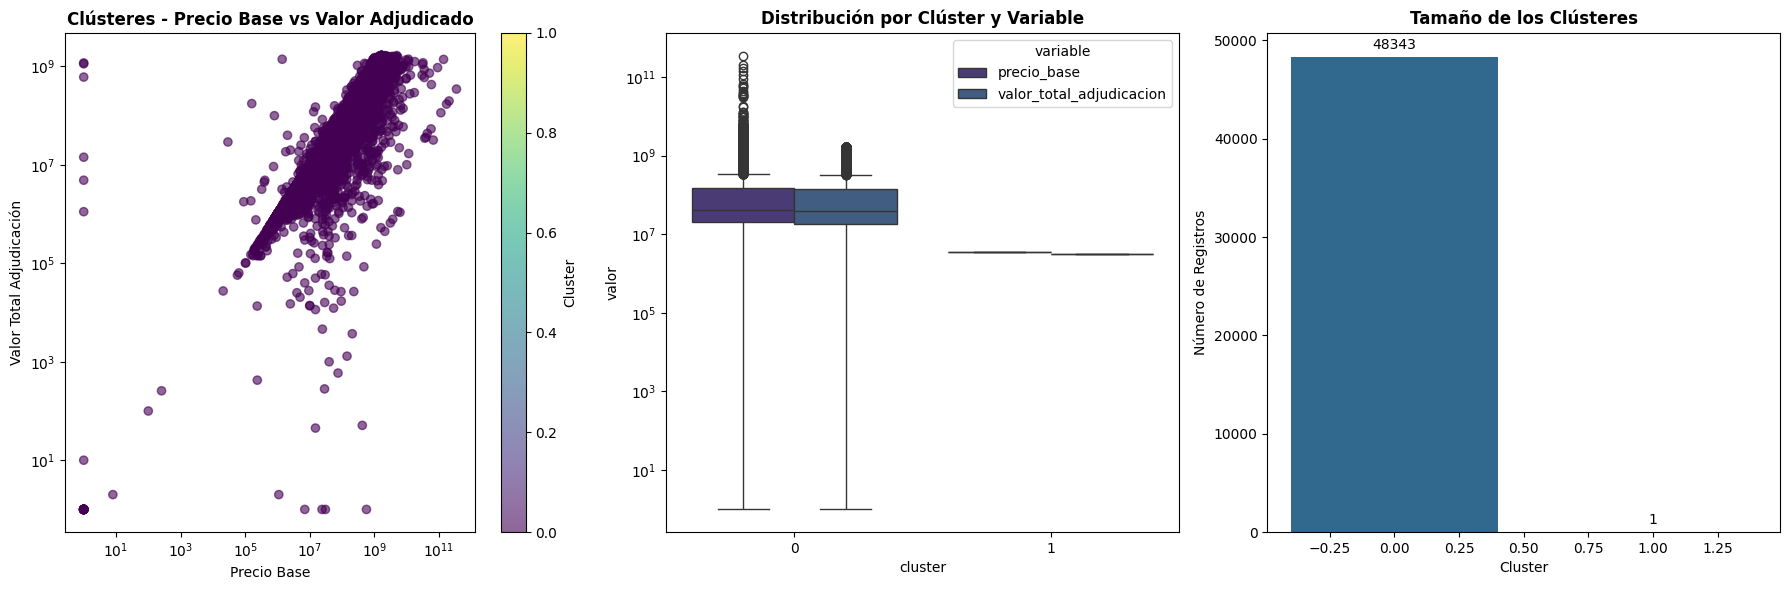

In [55]:
# 5.4 VISUALIZACIÓN DE CLÚSTERES
print("\n4. VISUALIZACIÓN DE CLÚSTERES")
print("-" * 40)

# Visualización 2D/3D de clusters
fig = plt.figure(figsize=(18, 6))

# Scatter plot 2D
plt.subplot(1, 3, 1)
scatter = plt.scatter(df_cluster_result['precio_base'],
                     df_cluster_result['valor_total_adjudicacion'],
                     c=df_cluster_result['cluster'], cmap='viridis', alpha=0.6)
plt.xlabel('Precio Base')
plt.ylabel('Valor Total Adjudicación')
plt.title('Clústeres - Precio Base vs Valor Adjudicado', fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.xscale('log')
plt.yscale('log')

# Boxplot por cluster
plt.subplot(1, 3, 2)
df_melted = pd.melt(df_cluster_result, id_vars=['cluster'],
                   value_vars=['precio_base', 'valor_total_adjudicacion'],
                   var_name='variable', value_name='valor')
sns.boxplot(data=df_melted, x='cluster', y='valor', hue='variable')
plt.title('Distribución por Clúster y Variable', fontweight='bold')
plt.yscale('log')

# Tamaño de clusters
plt.subplot(1, 3, 3)
cluster_sizes = df_cluster_result['cluster'].value_counts().sort_index()
plt.bar(cluster_sizes.index, cluster_sizes.values, color=sns.color_palette("viridis", optimal_k))
plt.xlabel('Cluster')
plt.ylabel('Número de Registros')
plt.title('Tamaño de los Clústeres', fontweight='bold')
for i, v in enumerate(cluster_sizes.values):
    plt.text(i, v + 0.01*max(cluster_sizes.values), str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()


5. CLUSTERING JERÁRQUICO
----------------------------------------


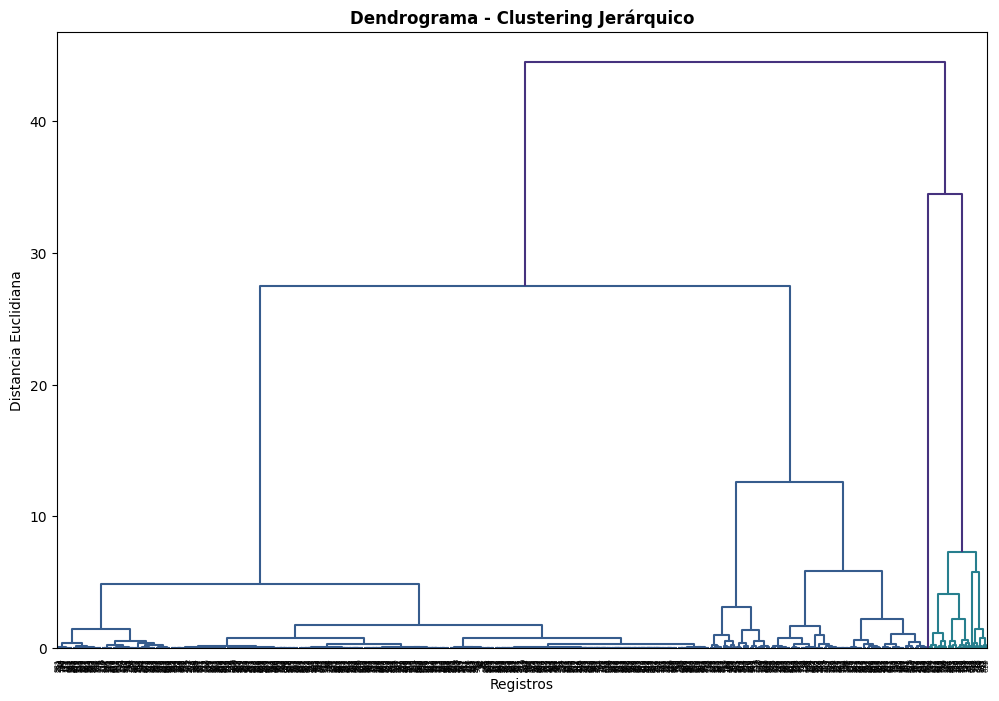

In [ ]:
# 5.5 CLUSTERING JERÁRQUICO
print("\n5. CLUSTERING JERÁRQUICO")
print("-" * 40)

# Aplicar clustering jerárquico (usando muestra por eficiencia)
sample_size = min(1000, len(X_cluster))
X_sample = X_cluster[:sample_size] if len(X_cluster) > sample_size else X_cluster

# Dendrograma
plt.figure(figsize=(12, 8))
dendrogram = sch.dendrogram(sch.linkage(X_sample, method='ward'))
plt.title('Dendrograma - Clustering Jerárquico', fontweight='bold')
plt.xlabel('Registros')
plt.ylabel('Distancia Euclidiana')
plt.show()

# Aplicar clustering jerárquico aglomerativo
hierarchical = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_cluster)

# Comparar con K-Means
comparison = pd.DataFrame({
    'KMeans': cluster_labels,
    'Hierarchical': hierarchical_labels
})

print("📊 COMPARACIÓN ENTRE K-MEANS Y CLUSTERING JERÁRQUICO:")
print(f"Coincidencia entre métodos: {(comparison['KMeans'] == comparison['Hierarchical']).mean():.1%}")